NOT FOUND - will need Runtime > Restart session and rerun
Configured font.serif priority: ['Times New Roman', 'DejaVu Serif']
AND GATE
Update 1
Input: [0 0], Target: 0
Weights: [-1.  0.  0.]

Saved: /content/plots/and_gate_update_1.eps


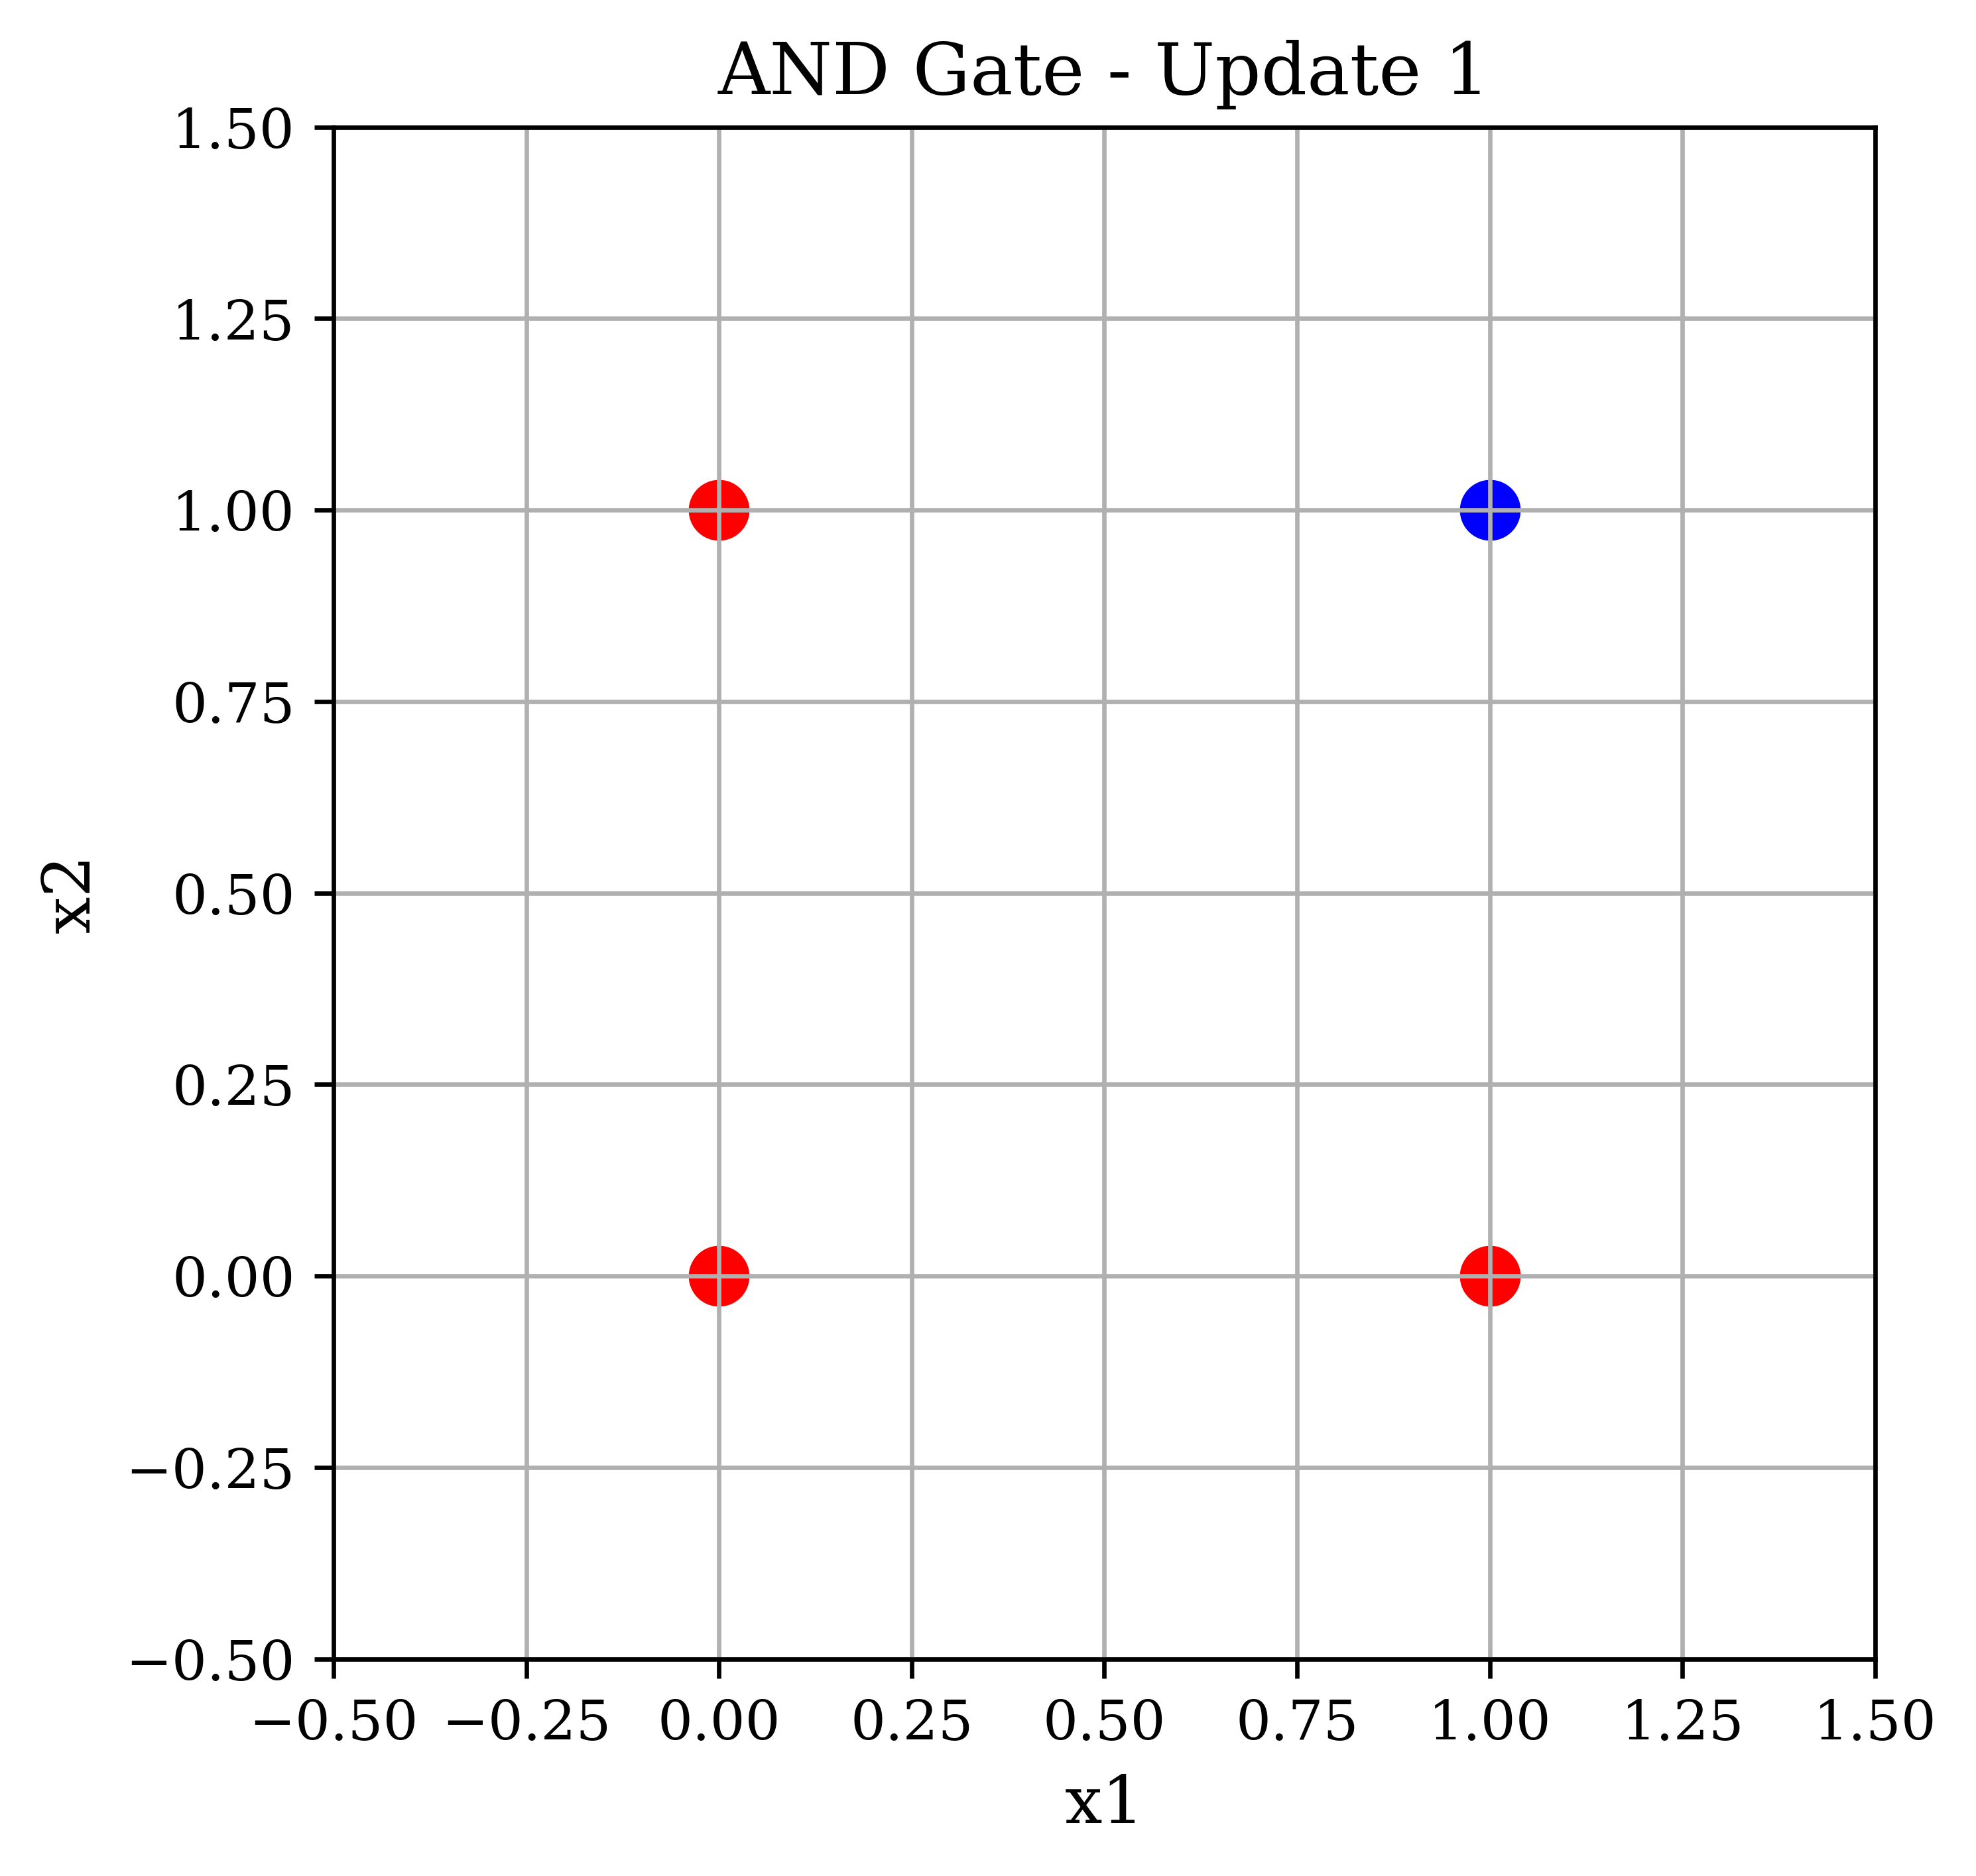

Update 2
Input: [1 1], Target: 1
Weights: [0. 1. 1.]

Saved: /content/plots/and_gate_update_2.eps


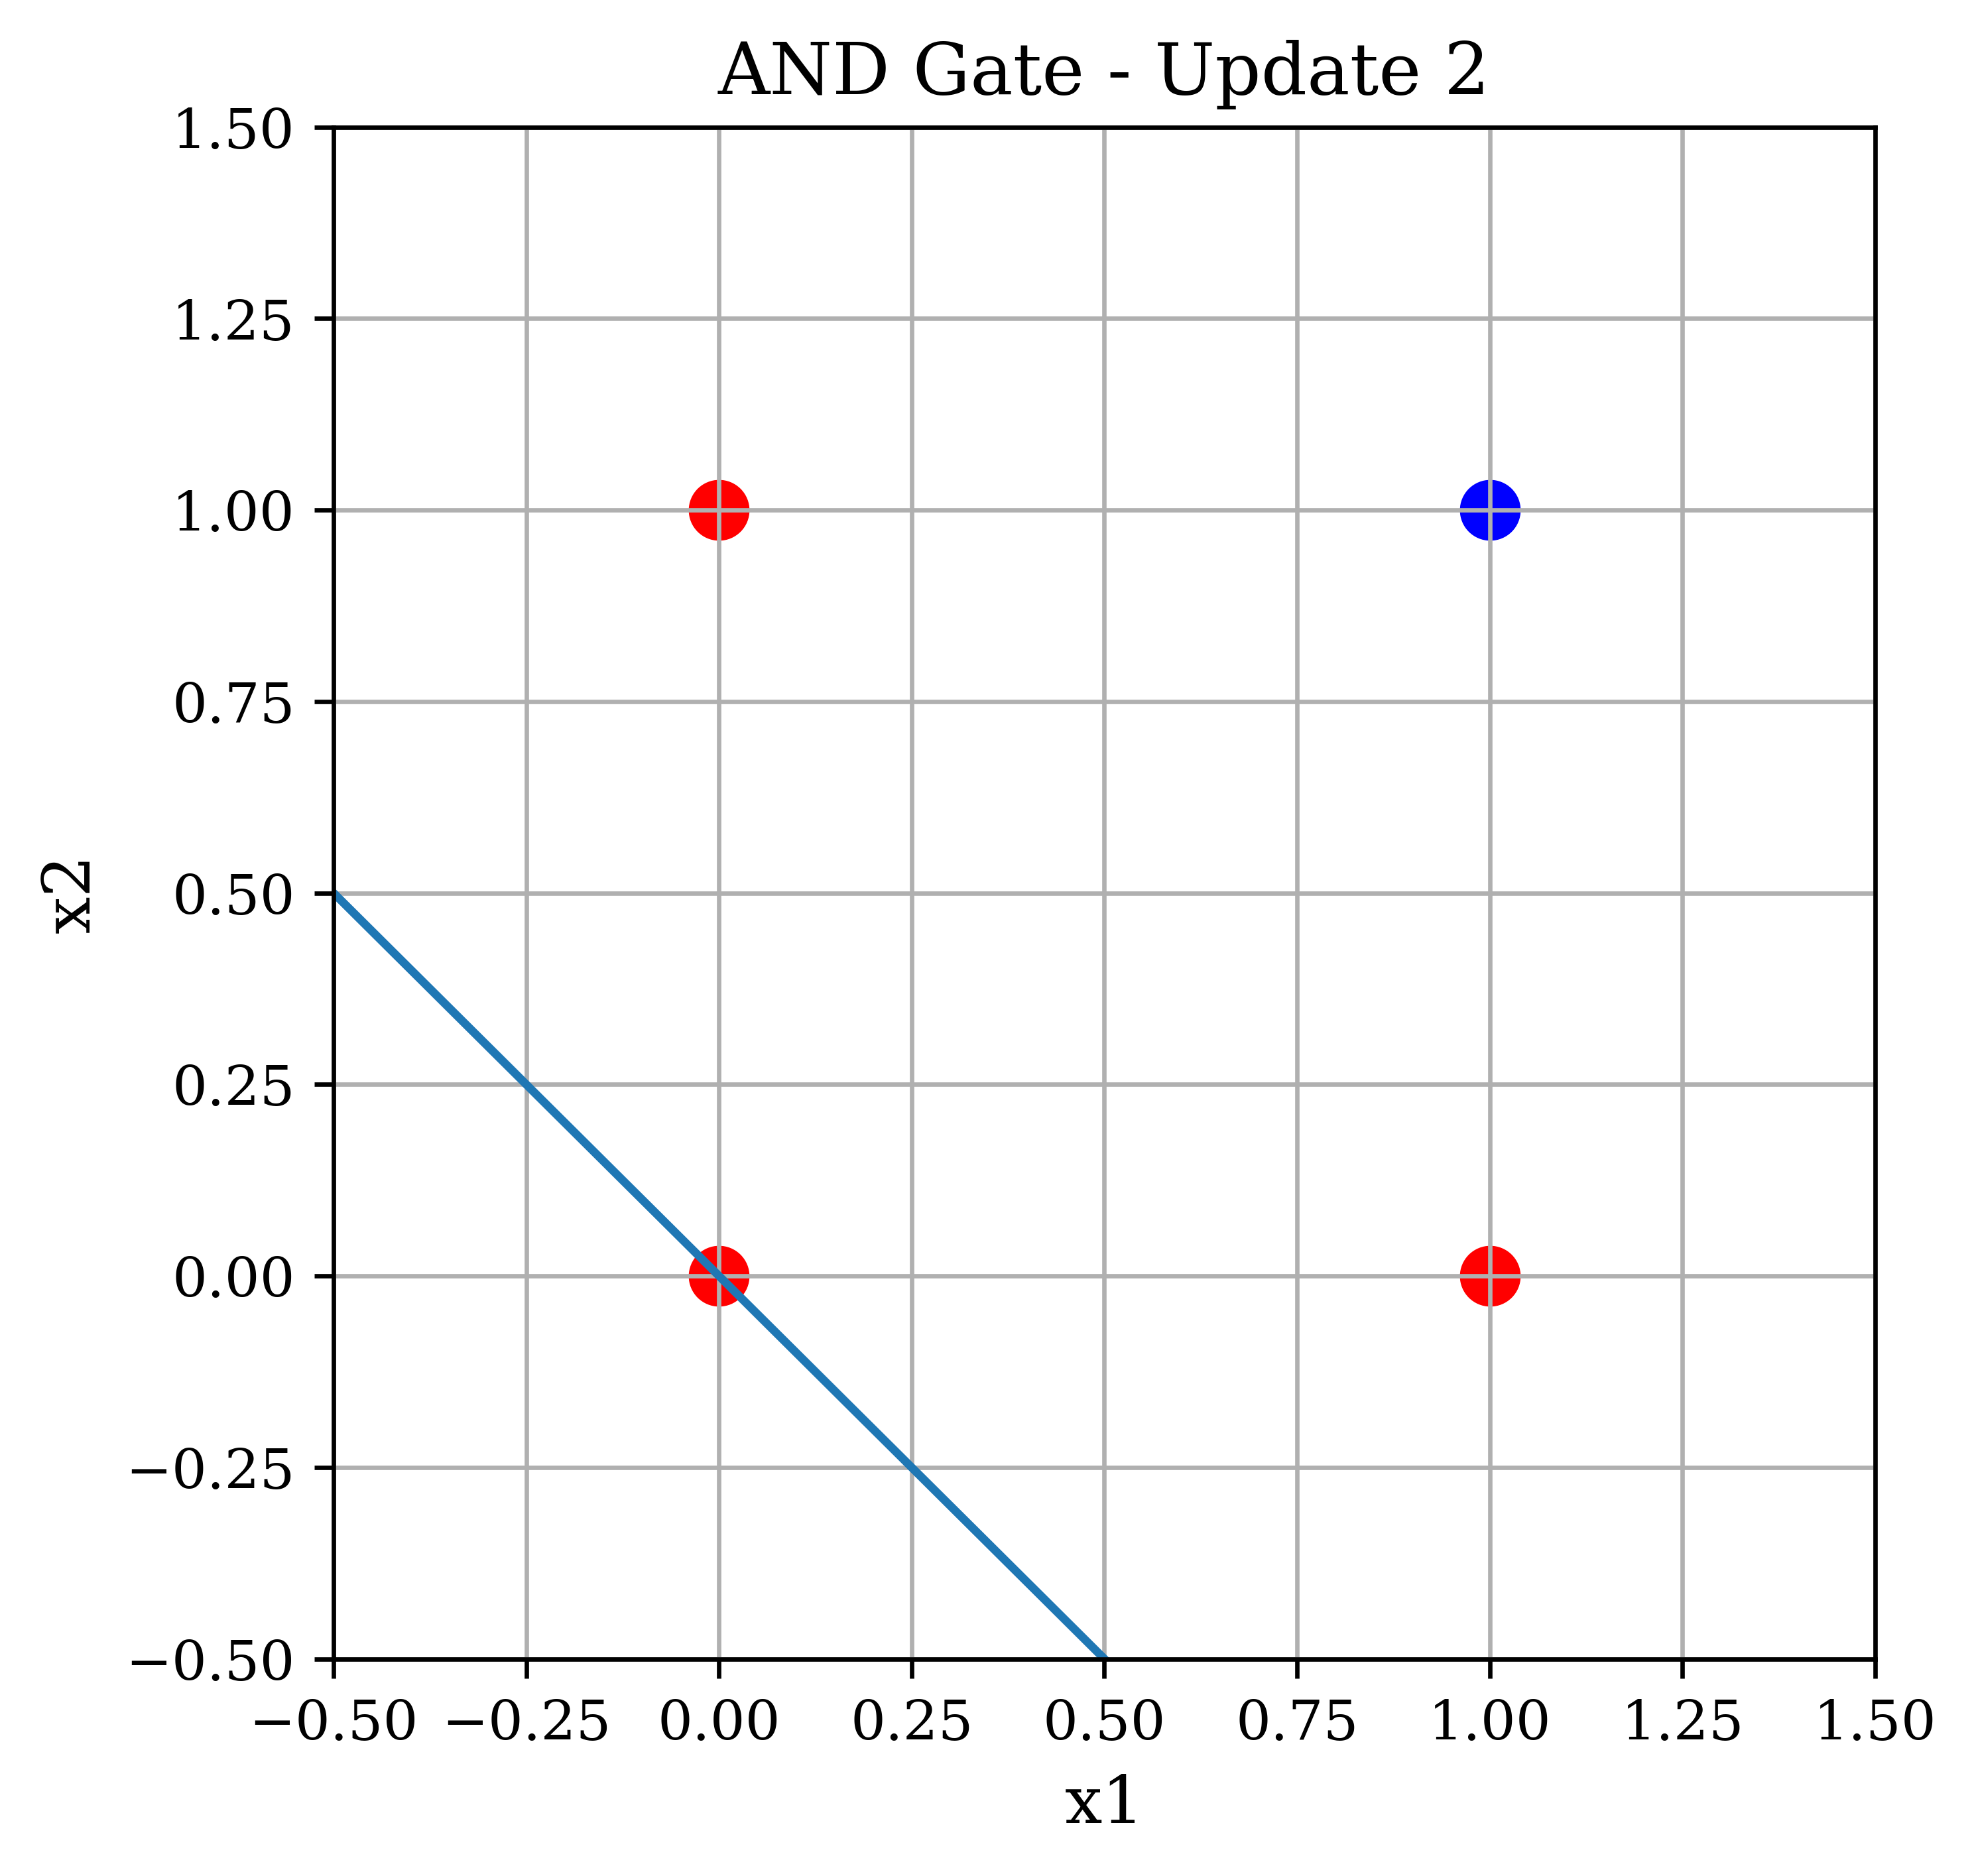

Update 3
Input: [0 0], Target: 0
Weights: [-1.  1.  1.]

Saved: /content/plots/and_gate_update_3.eps


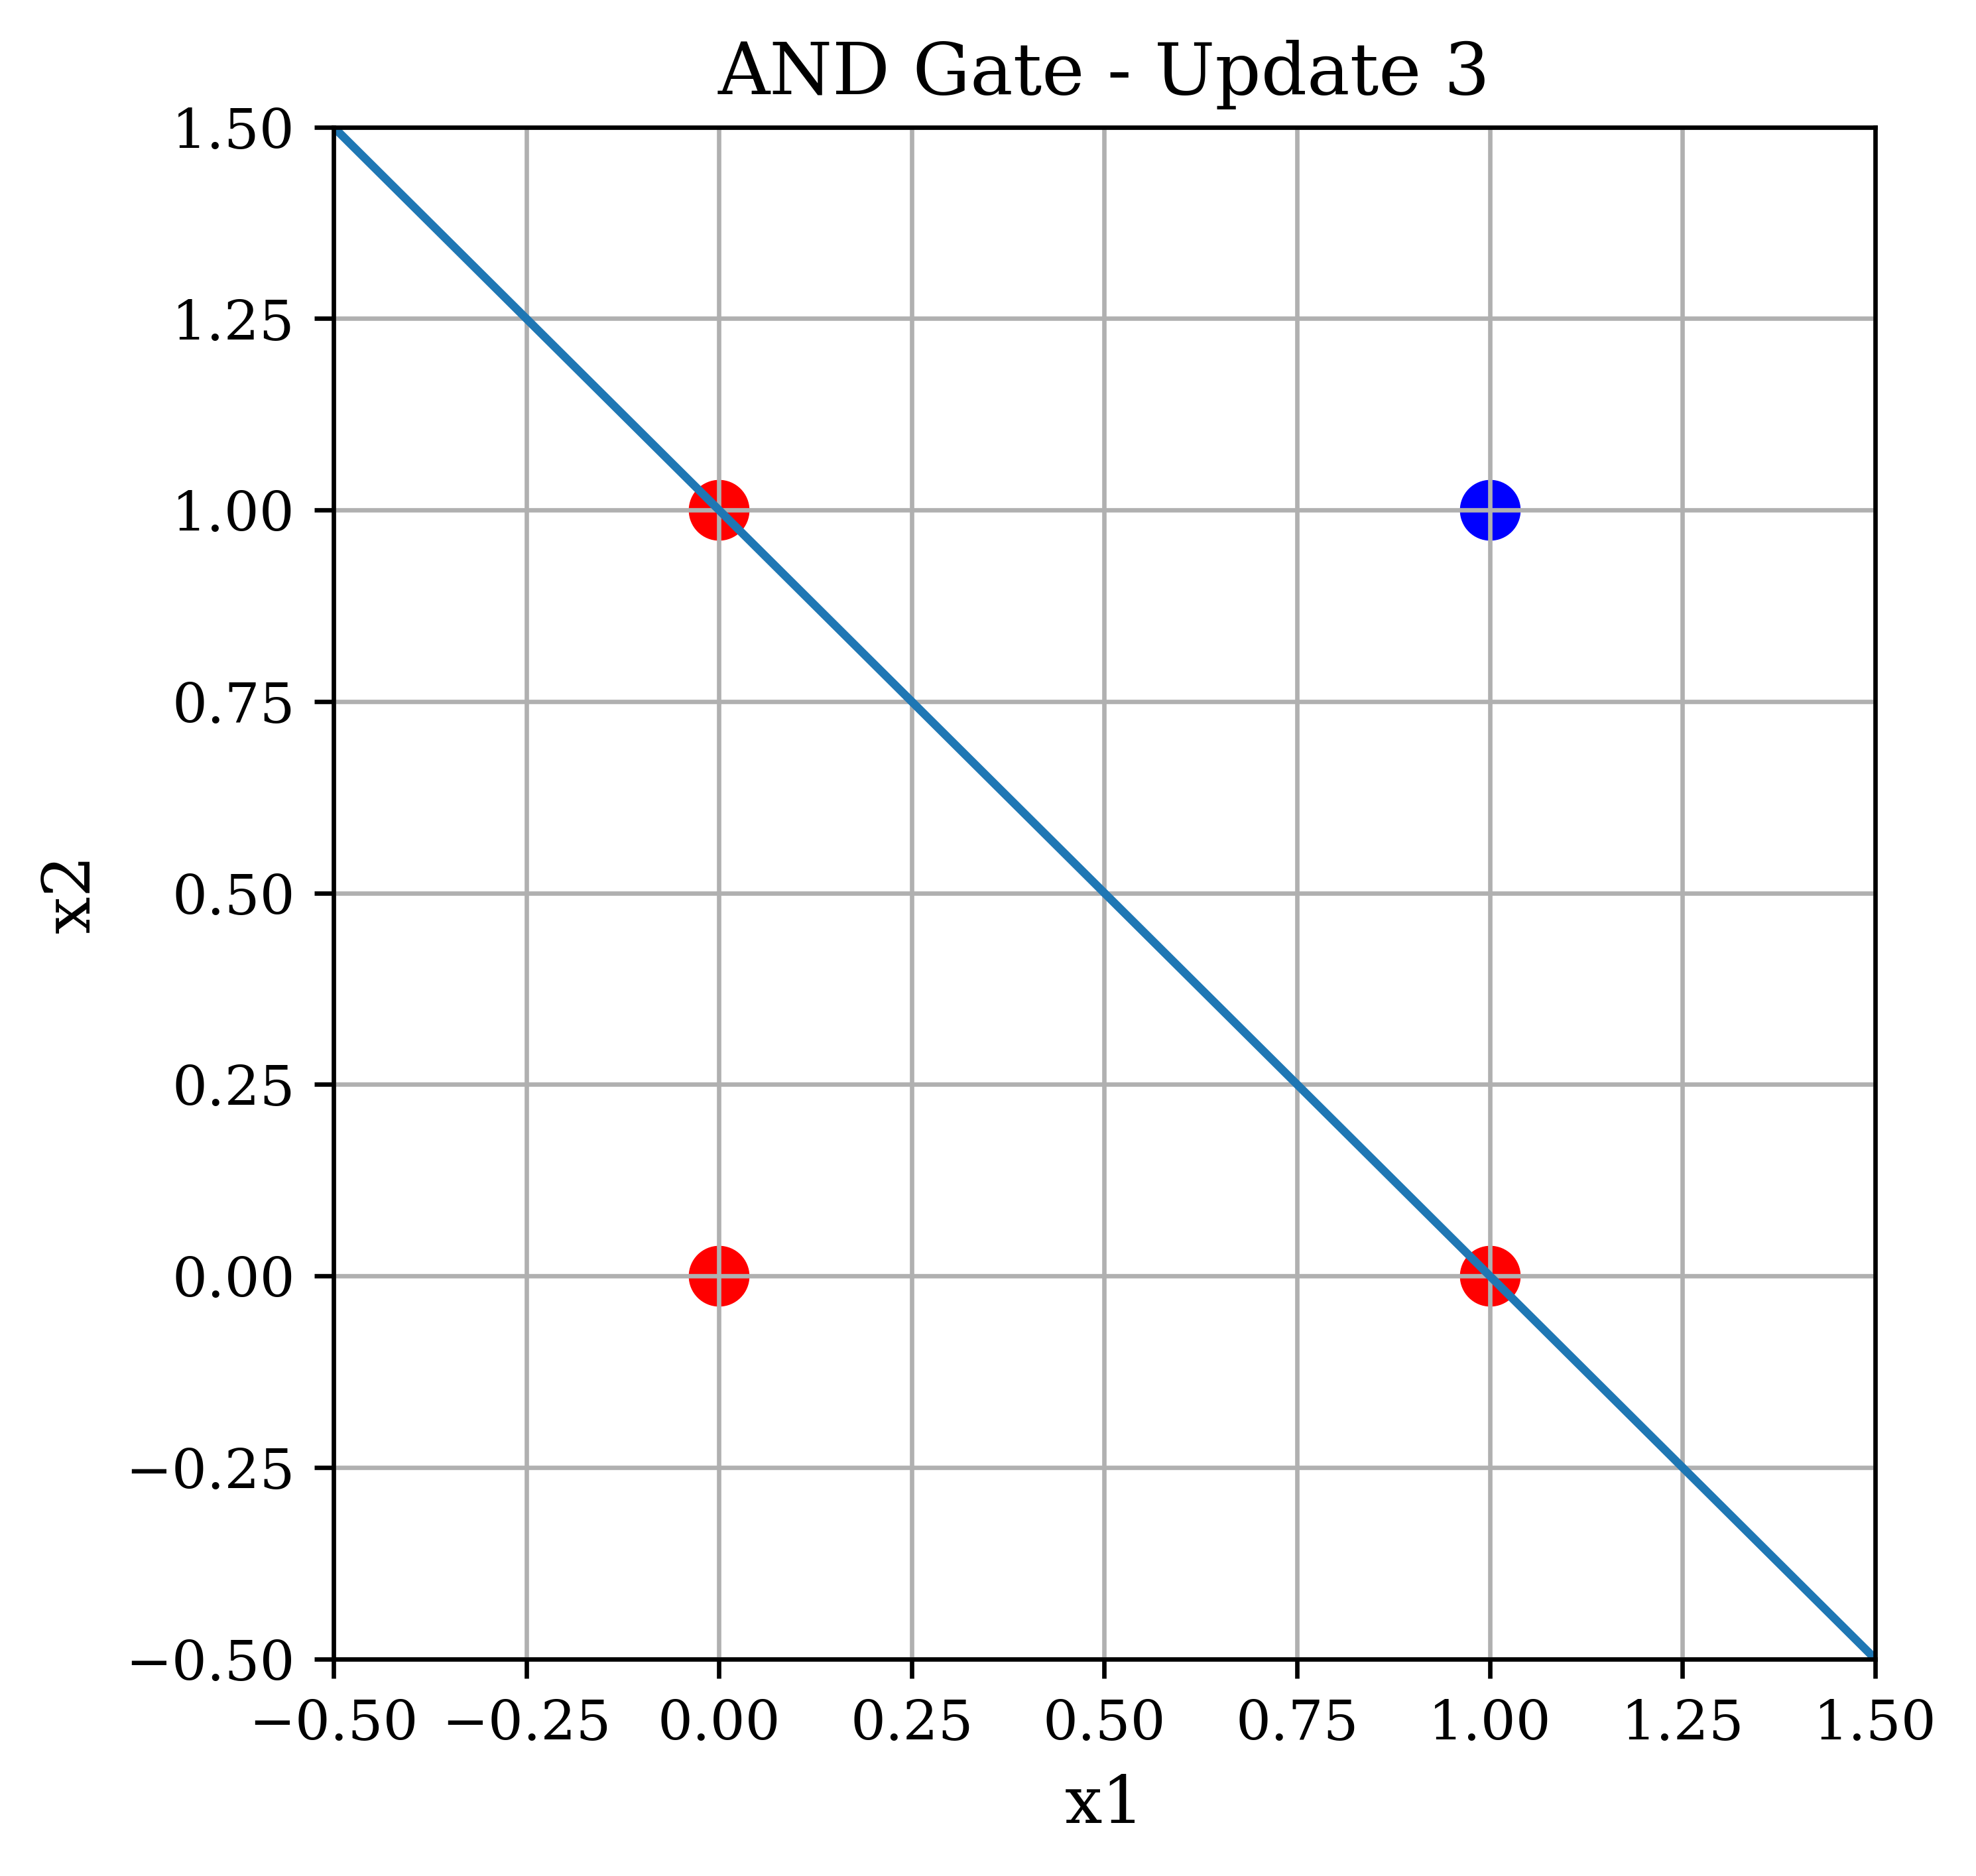

Update 4
Input: [0 1], Target: 0
Weights: [-2.  1.  0.]

Saved: /content/plots/and_gate_update_4.eps


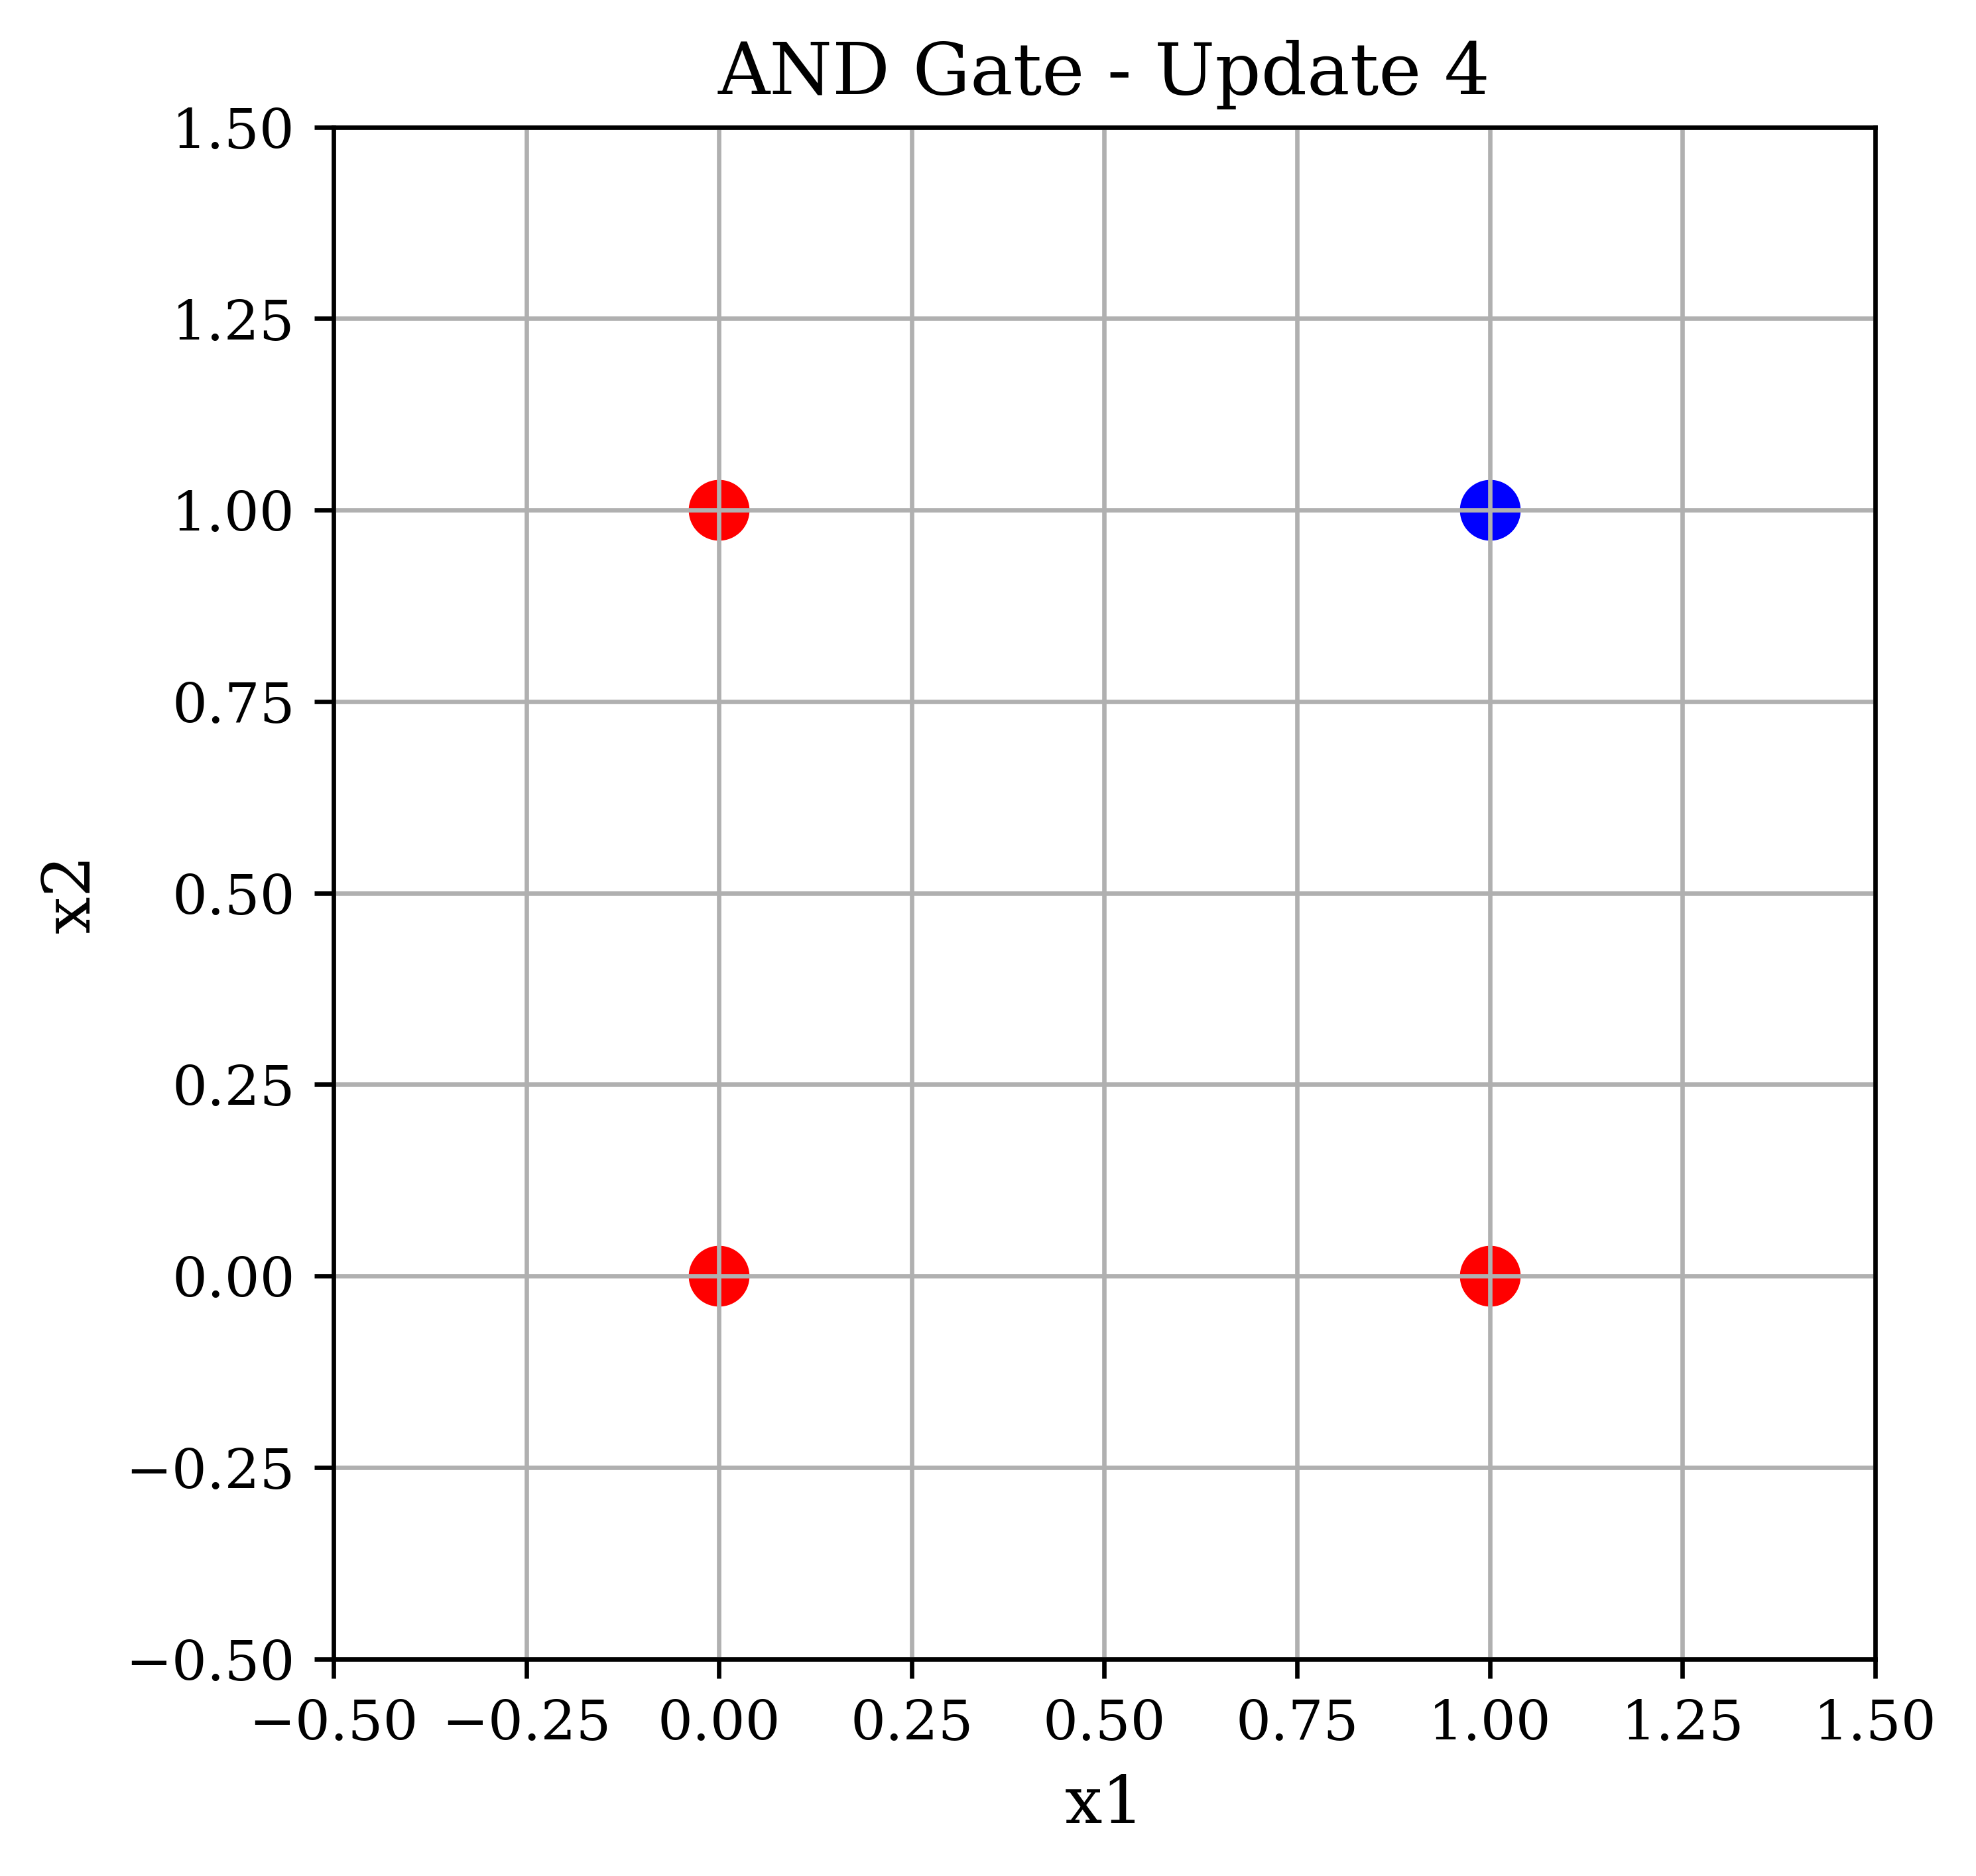

Update 5
Input: [1 1], Target: 1
Weights: [-1.  2.  1.]

Saved: /content/plots/and_gate_update_5.eps


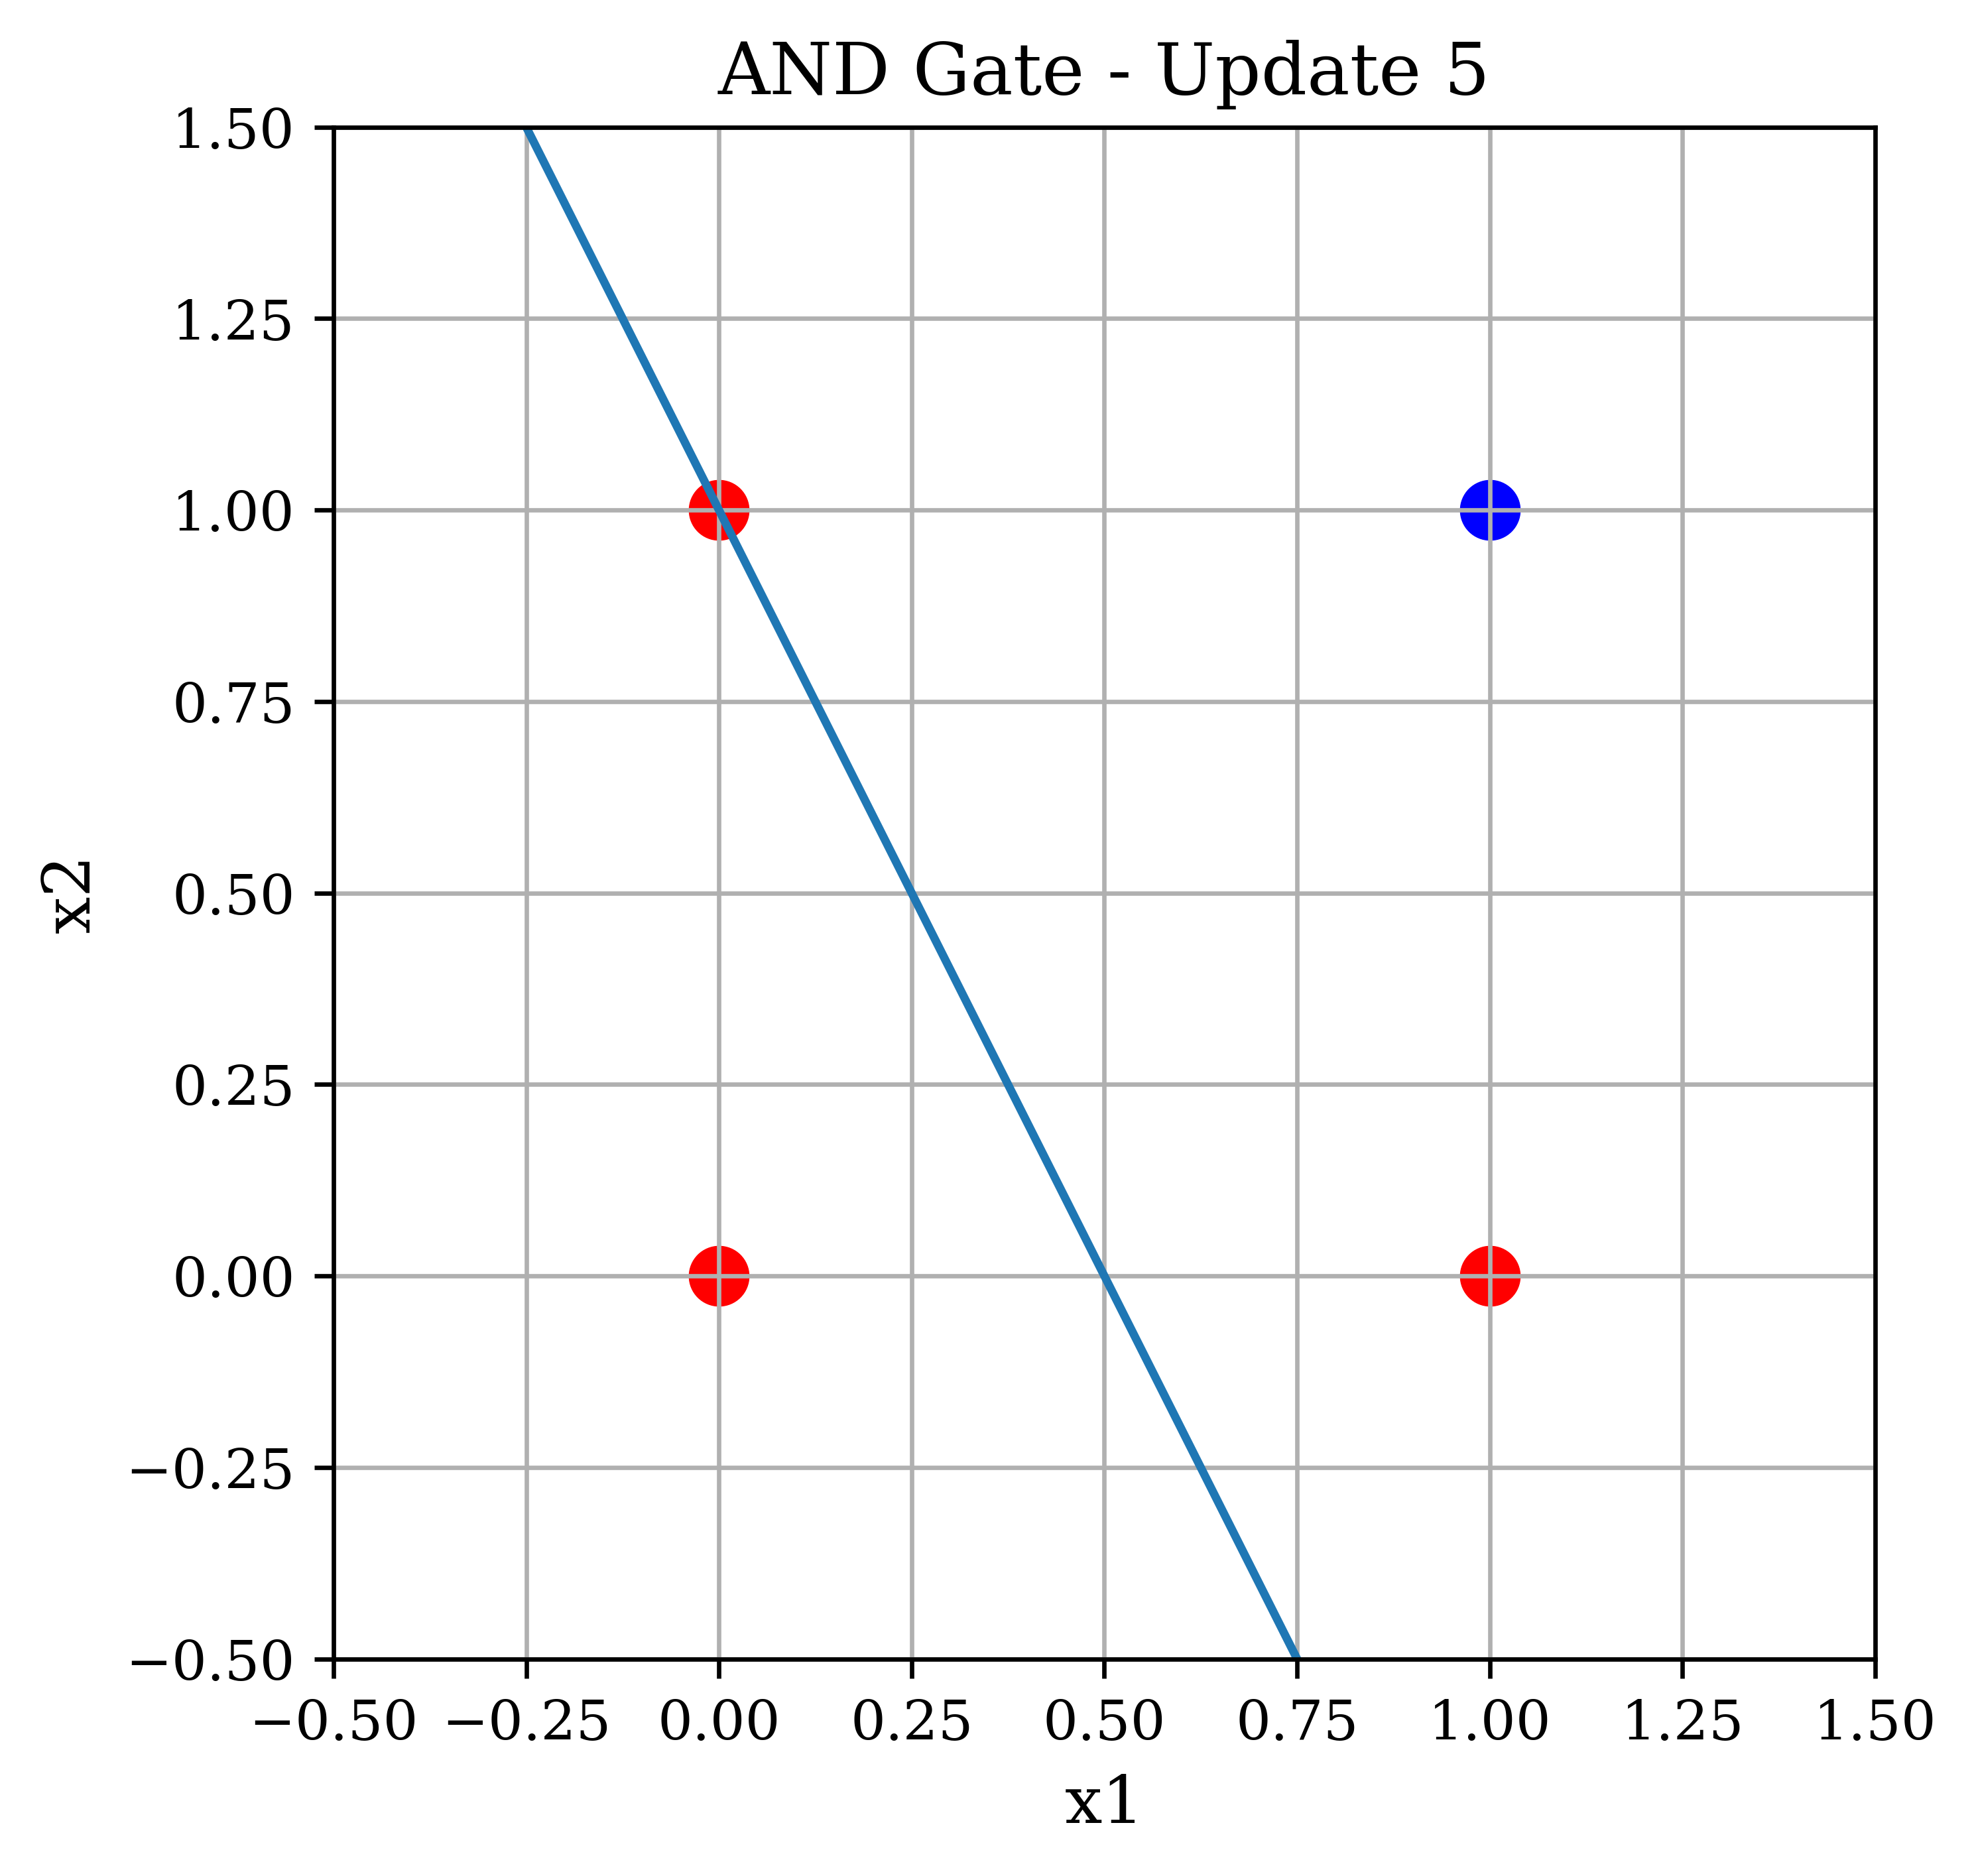

Update 6
Input: [0 1], Target: 0
Weights: [-2.  2.  0.]

Saved: /content/plots/and_gate_update_6.eps


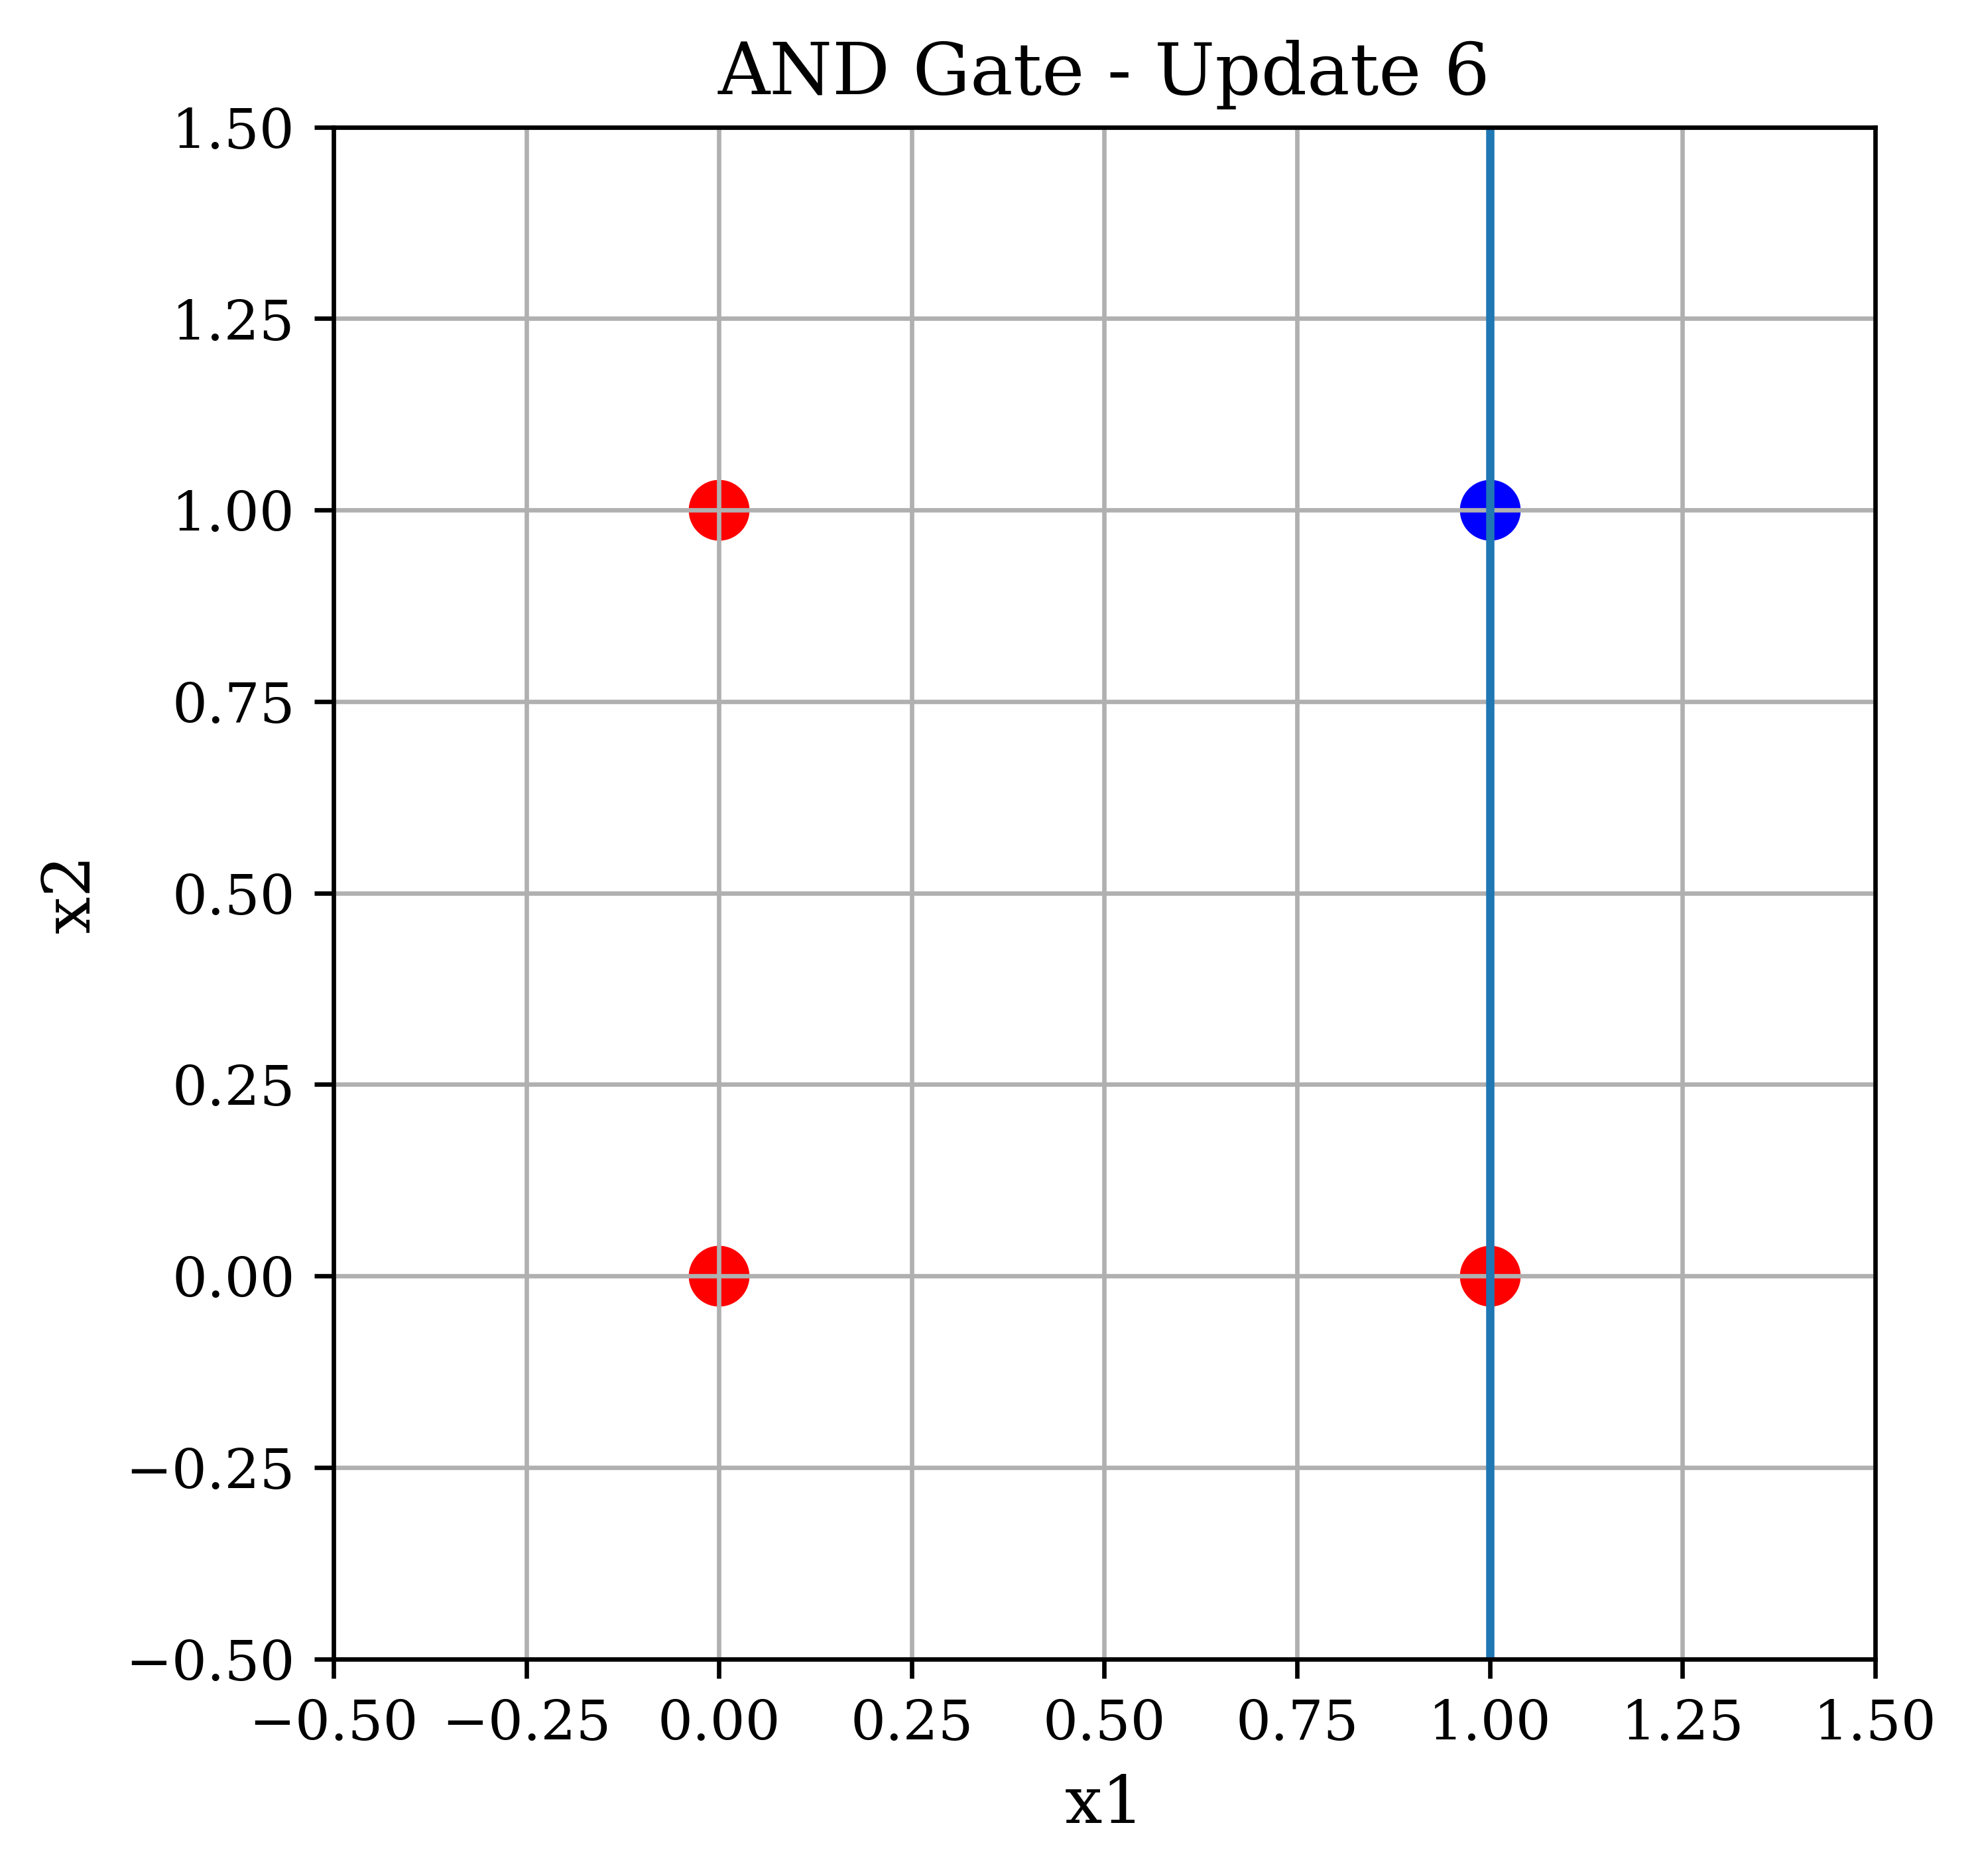

Update 7
Input: [1 0], Target: 0
Weights: [-3.  1.  0.]

Saved: /content/plots/and_gate_update_7.eps


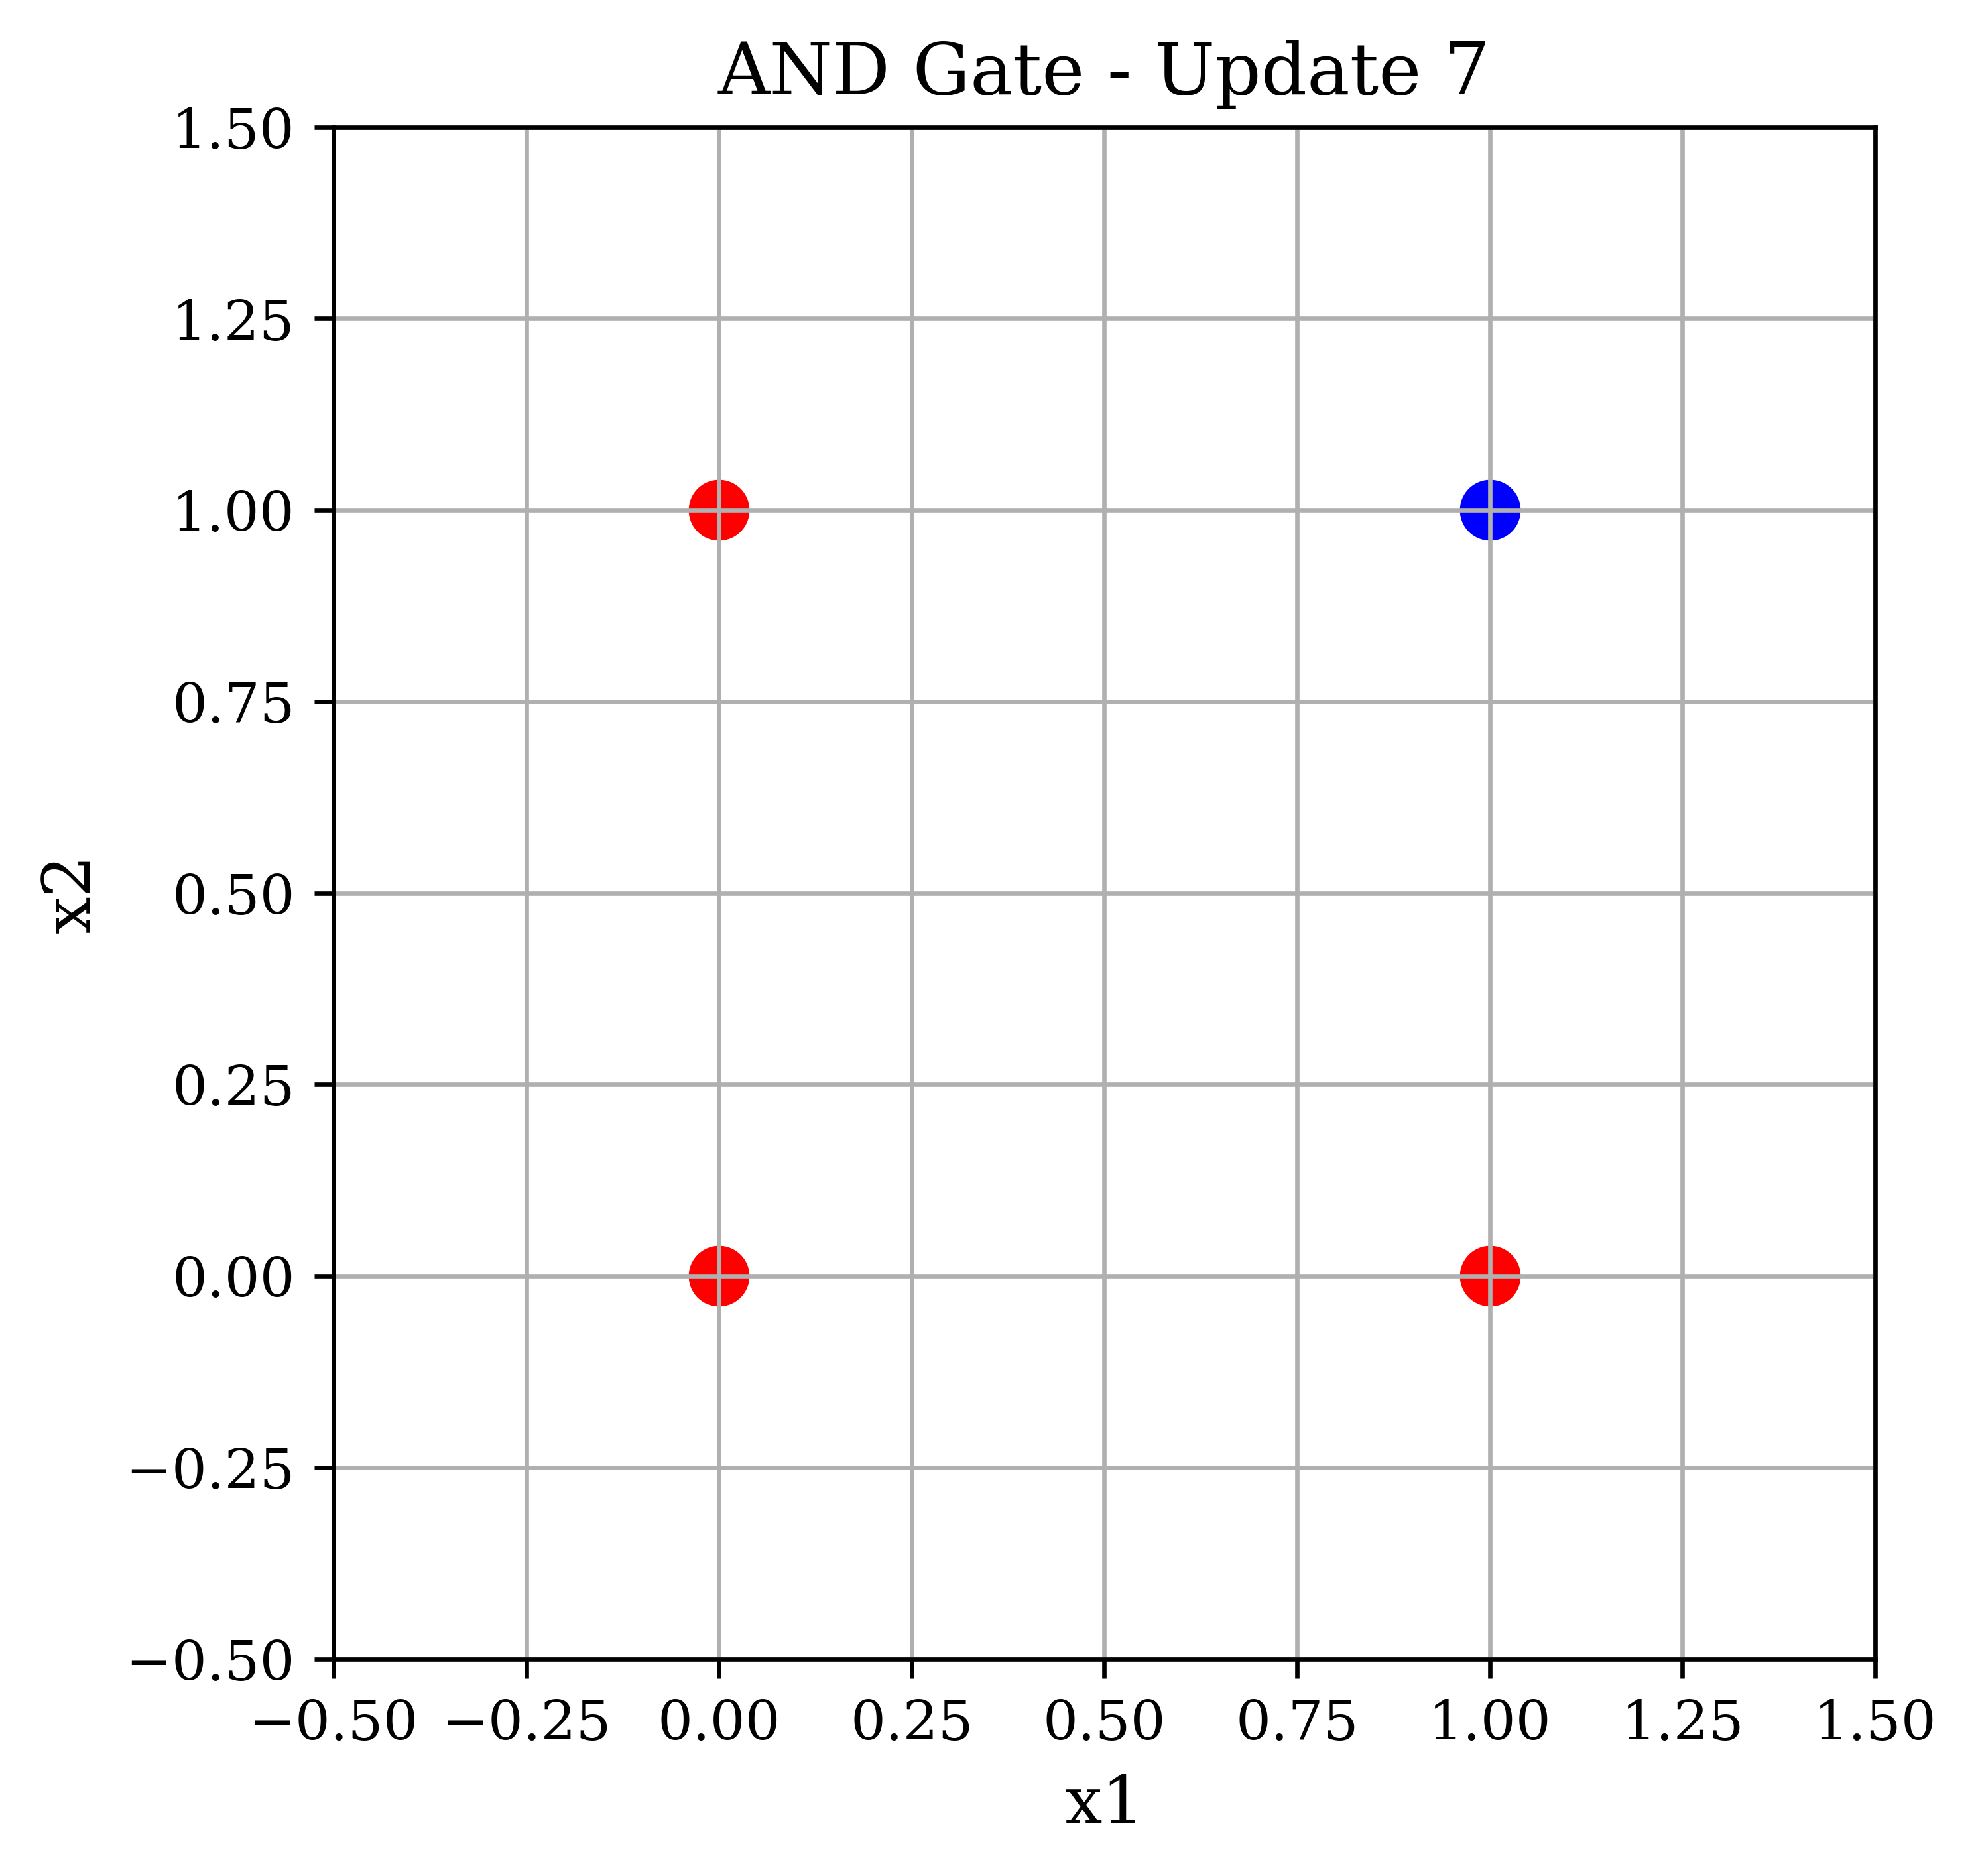

Update 8
Input: [1 1], Target: 1
Weights: [-2.  2.  1.]

Saved: /content/plots/and_gate_update_8.eps


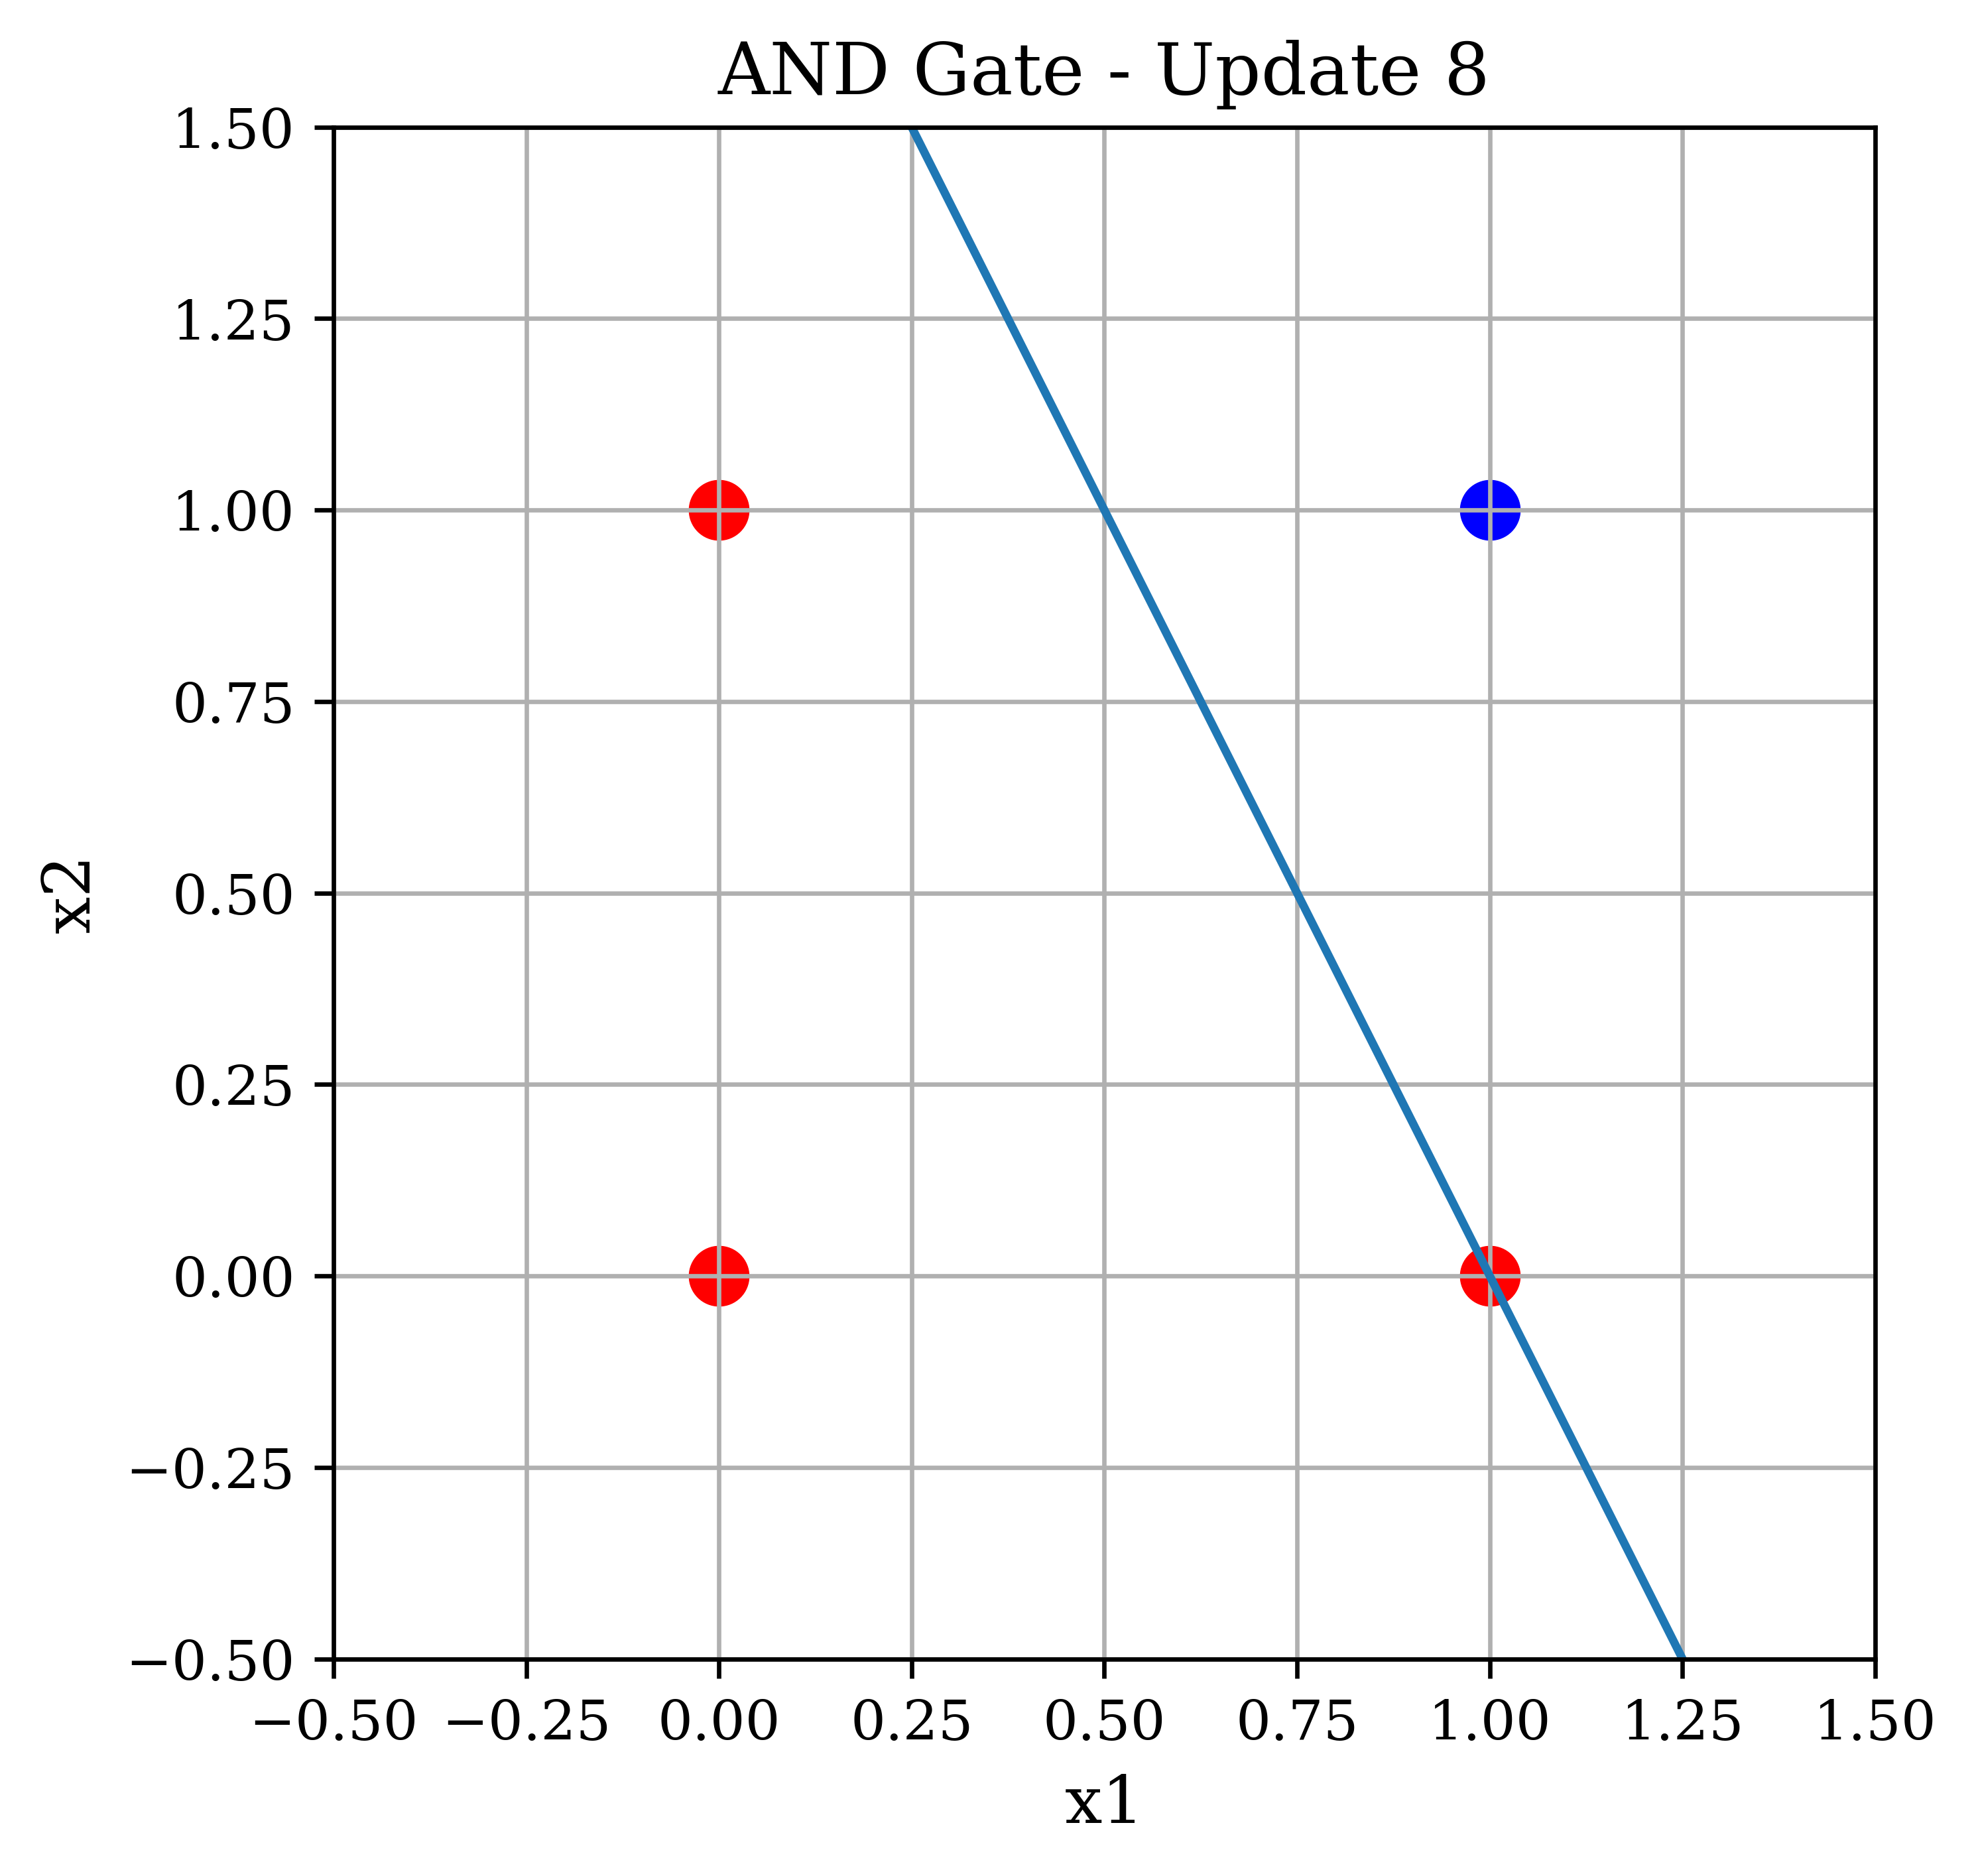

Update 9
Input: [1 0], Target: 0
Weights: [-3.  1.  1.]

Saved: /content/plots/and_gate_update_9.eps


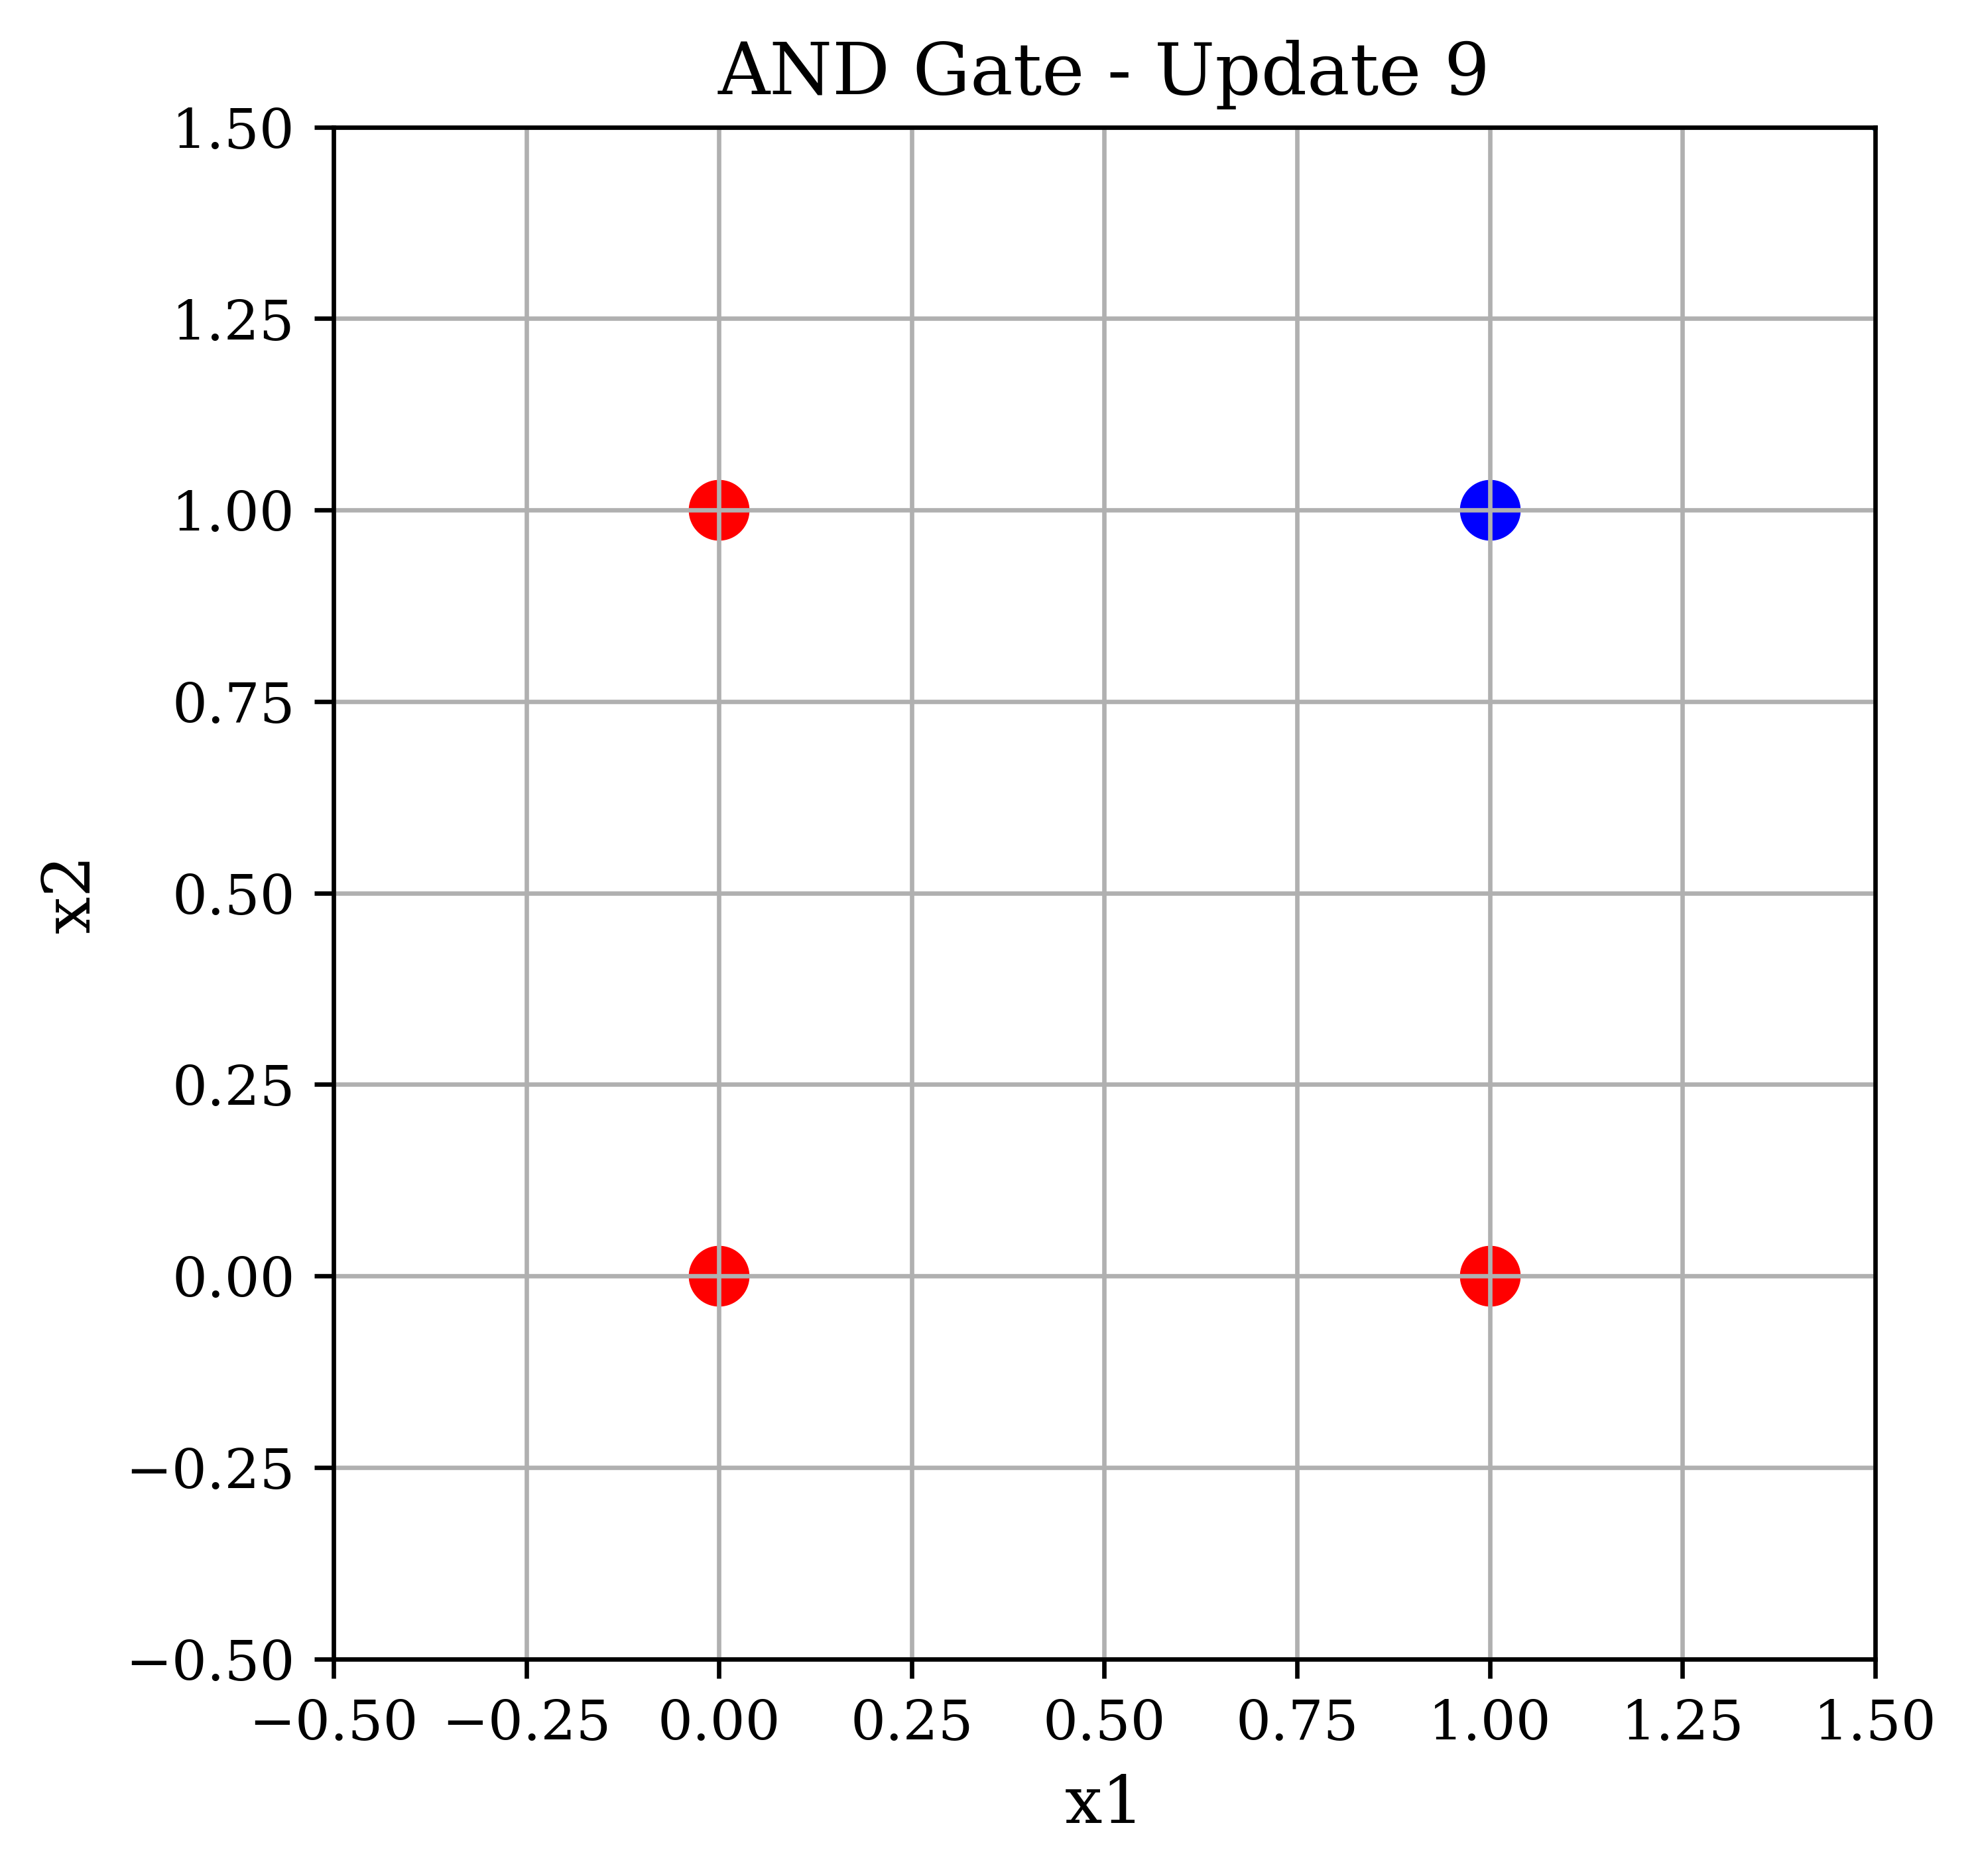

Update 10
Input: [1 1], Target: 1
Weights: [-2.  2.  2.]

Saved: /content/plots/and_gate_update_10.eps


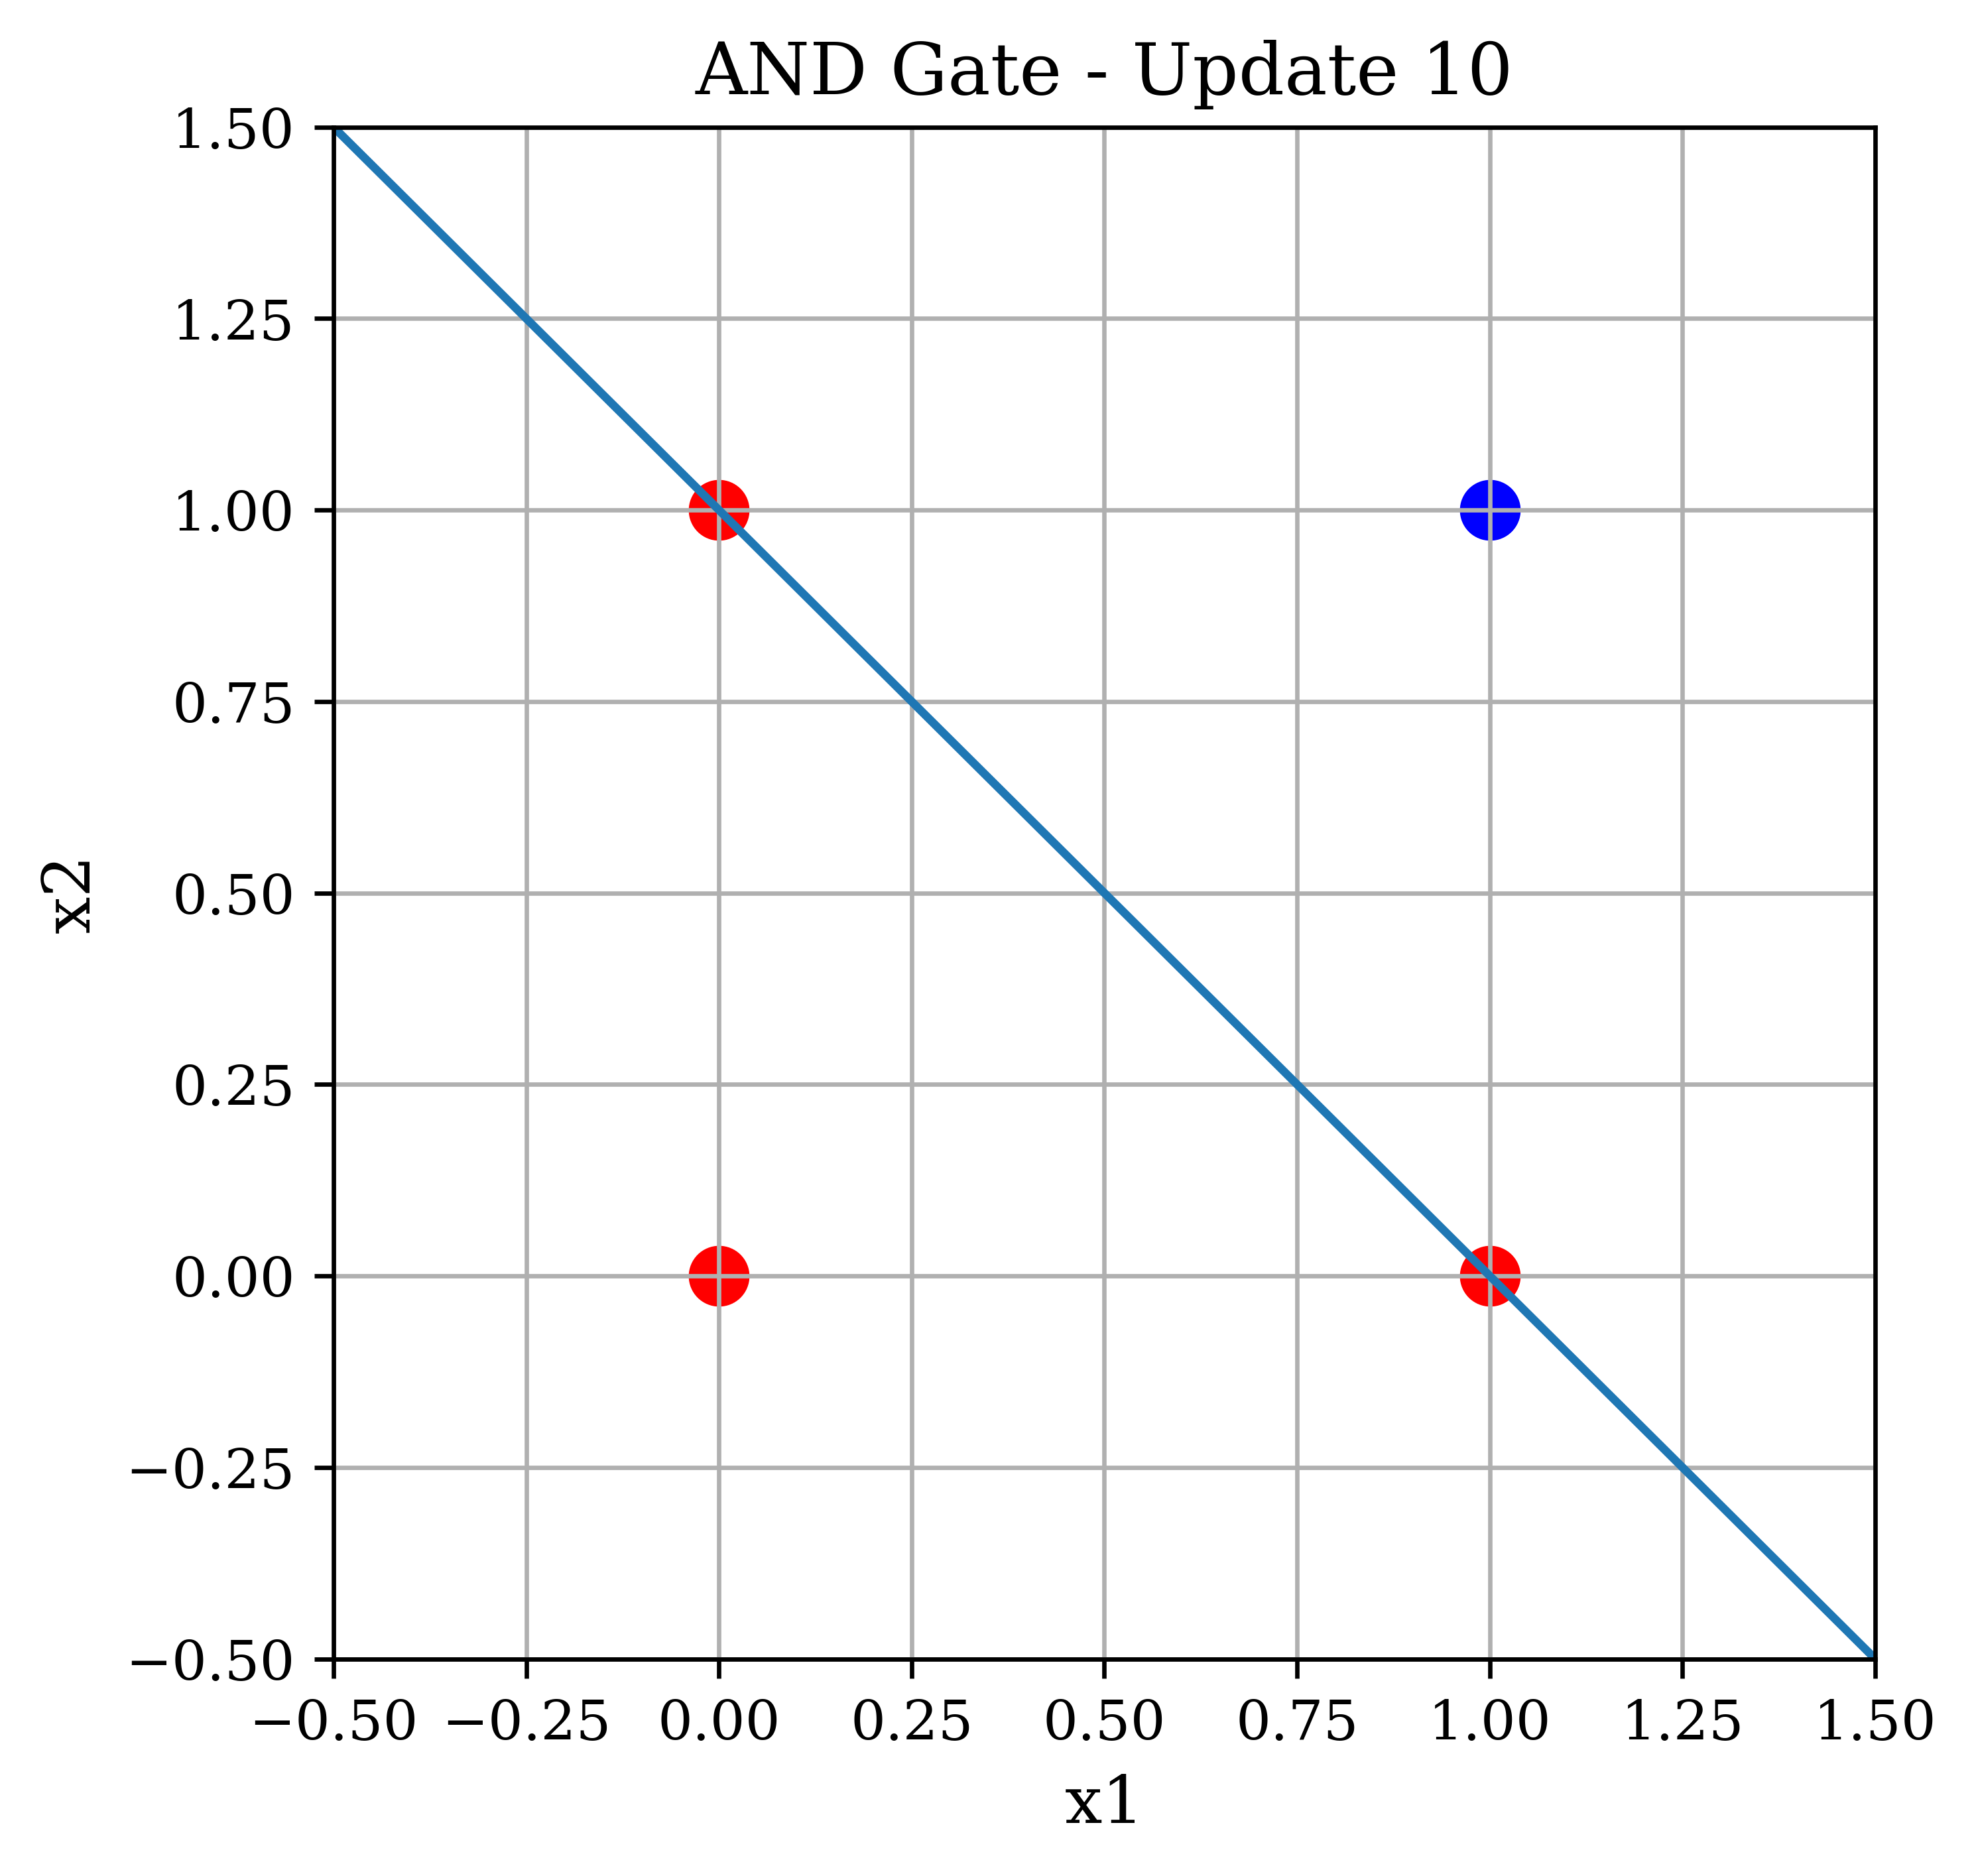

Update 11
Input: [0 1], Target: 0
Weights: [-3.  2.  1.]

Saved: /content/plots/and_gate_update_11.eps


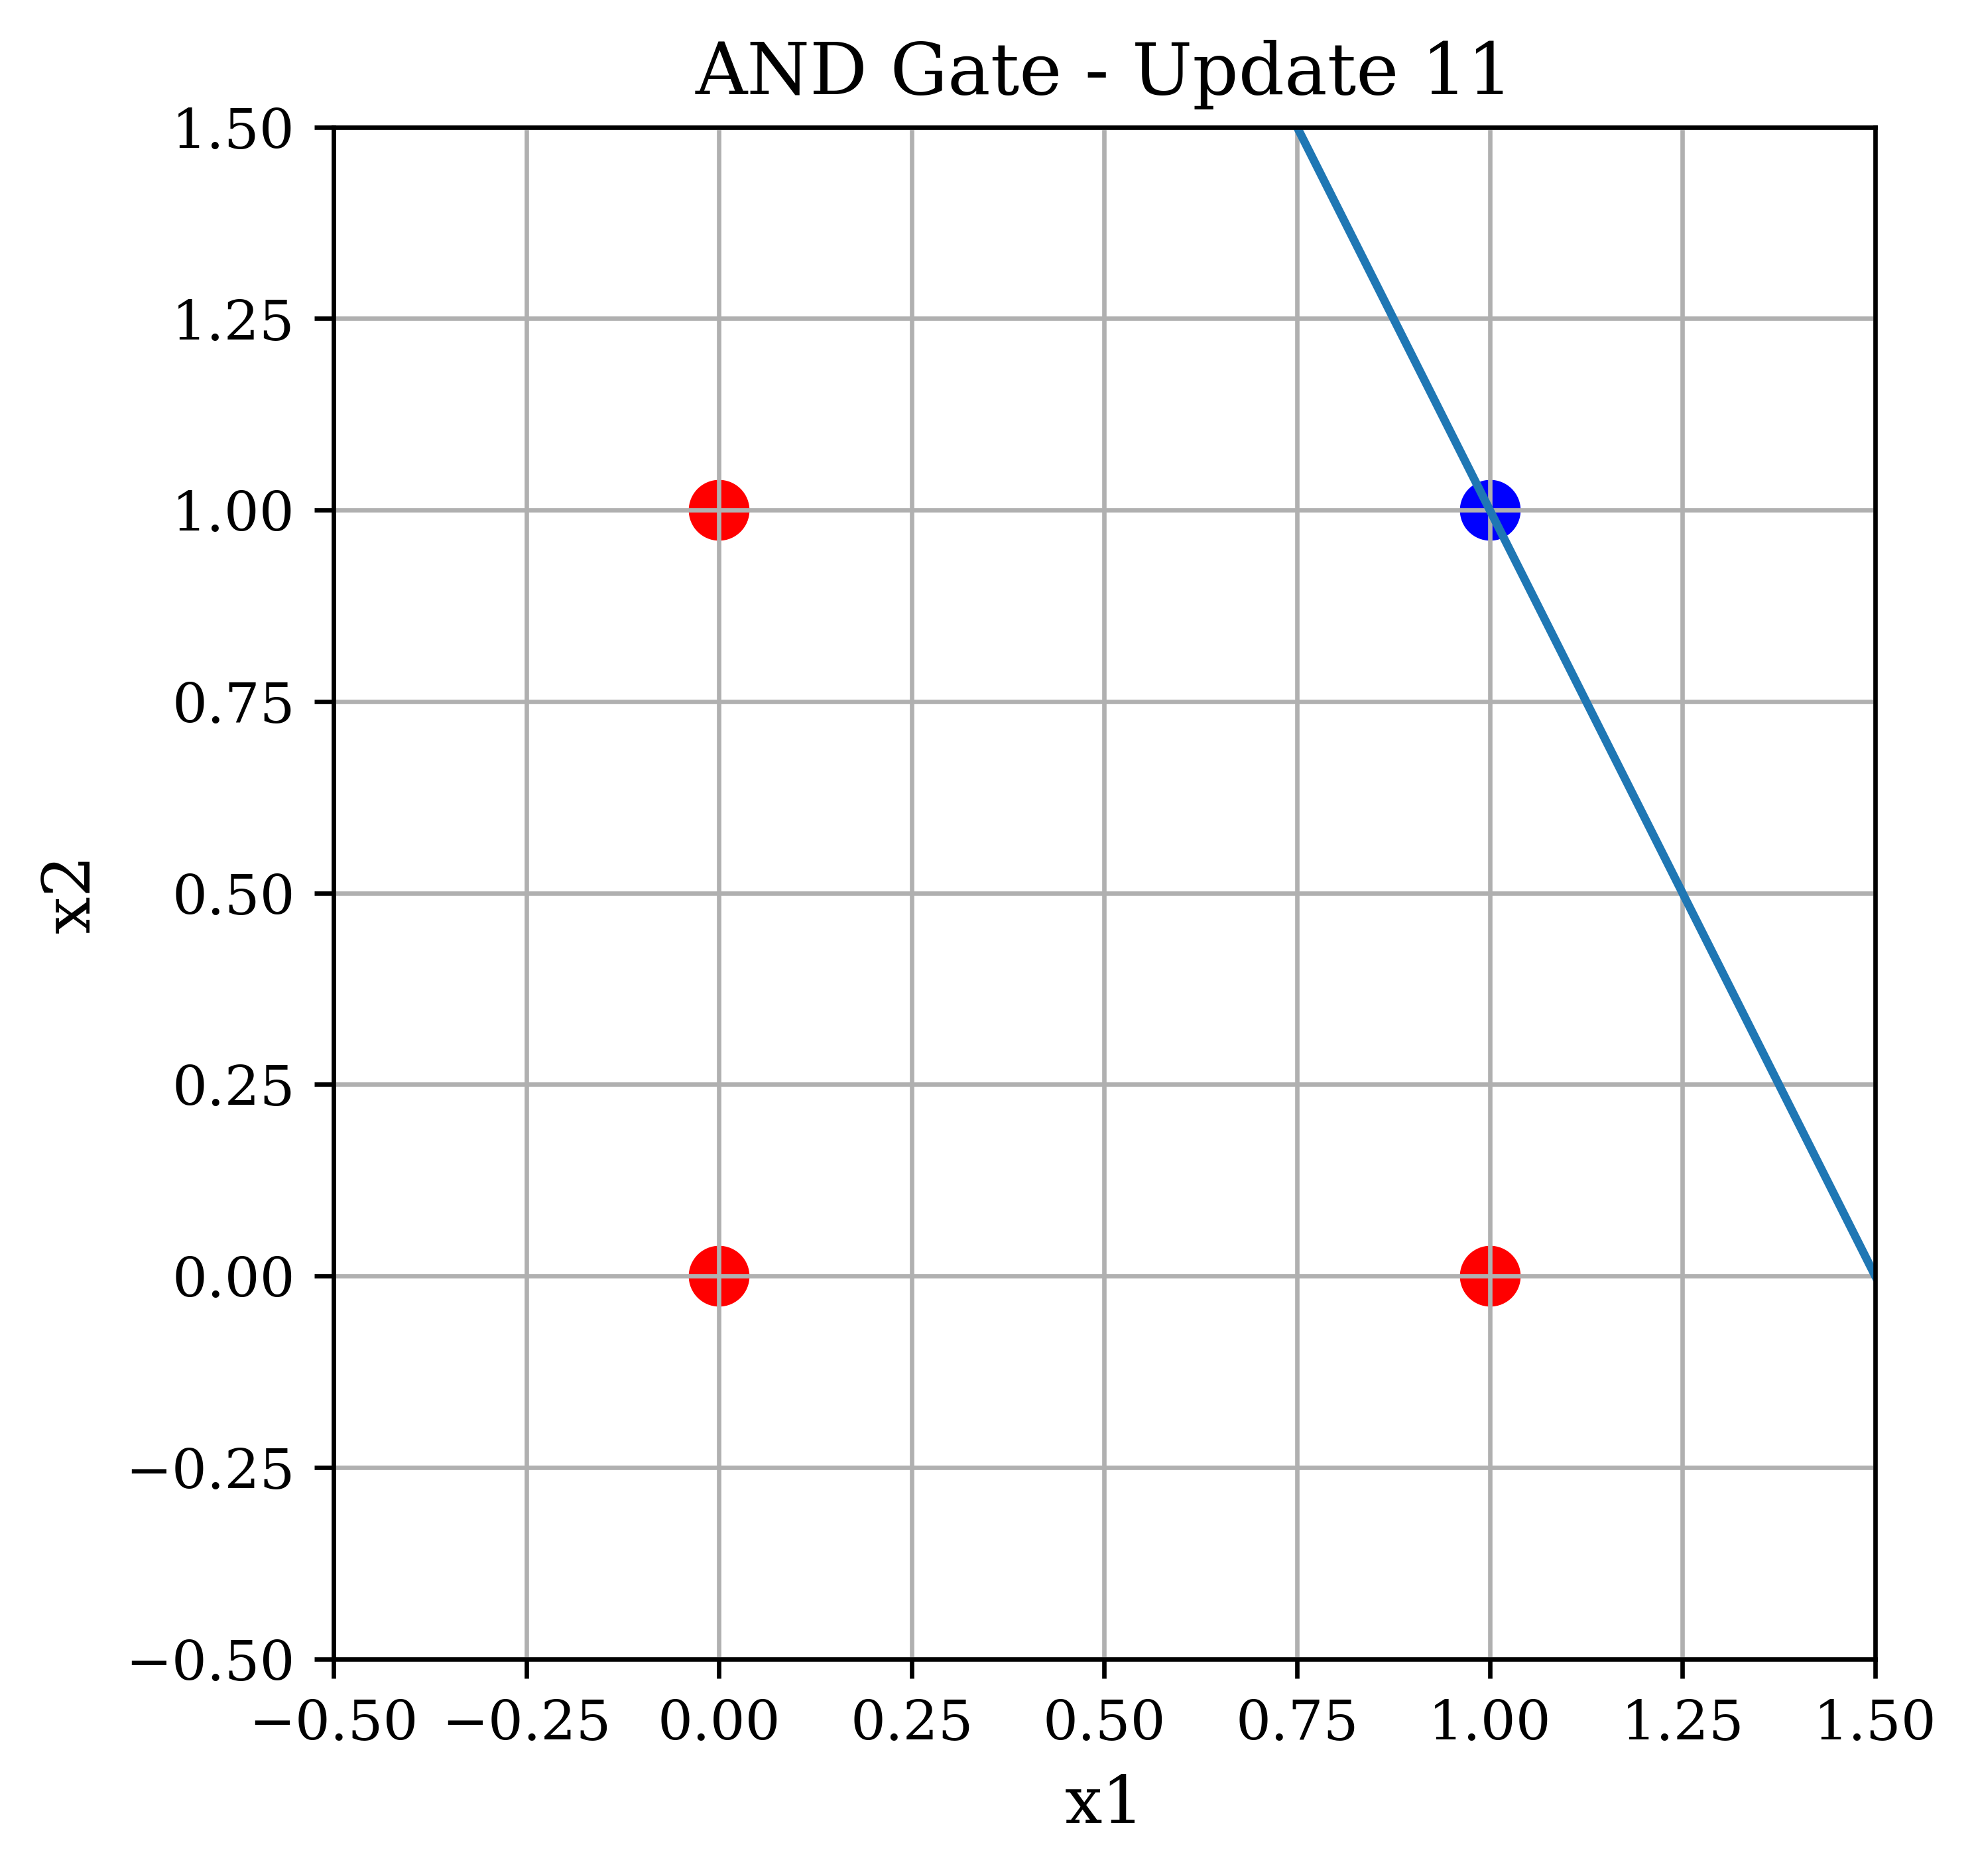

Converged after 6 epochs.

OR GATE
Update 1
Input: [0 0], Target: 0
Weights: [-1.  0.  0.]

Saved: /content/plots/or_gate_update_1.eps


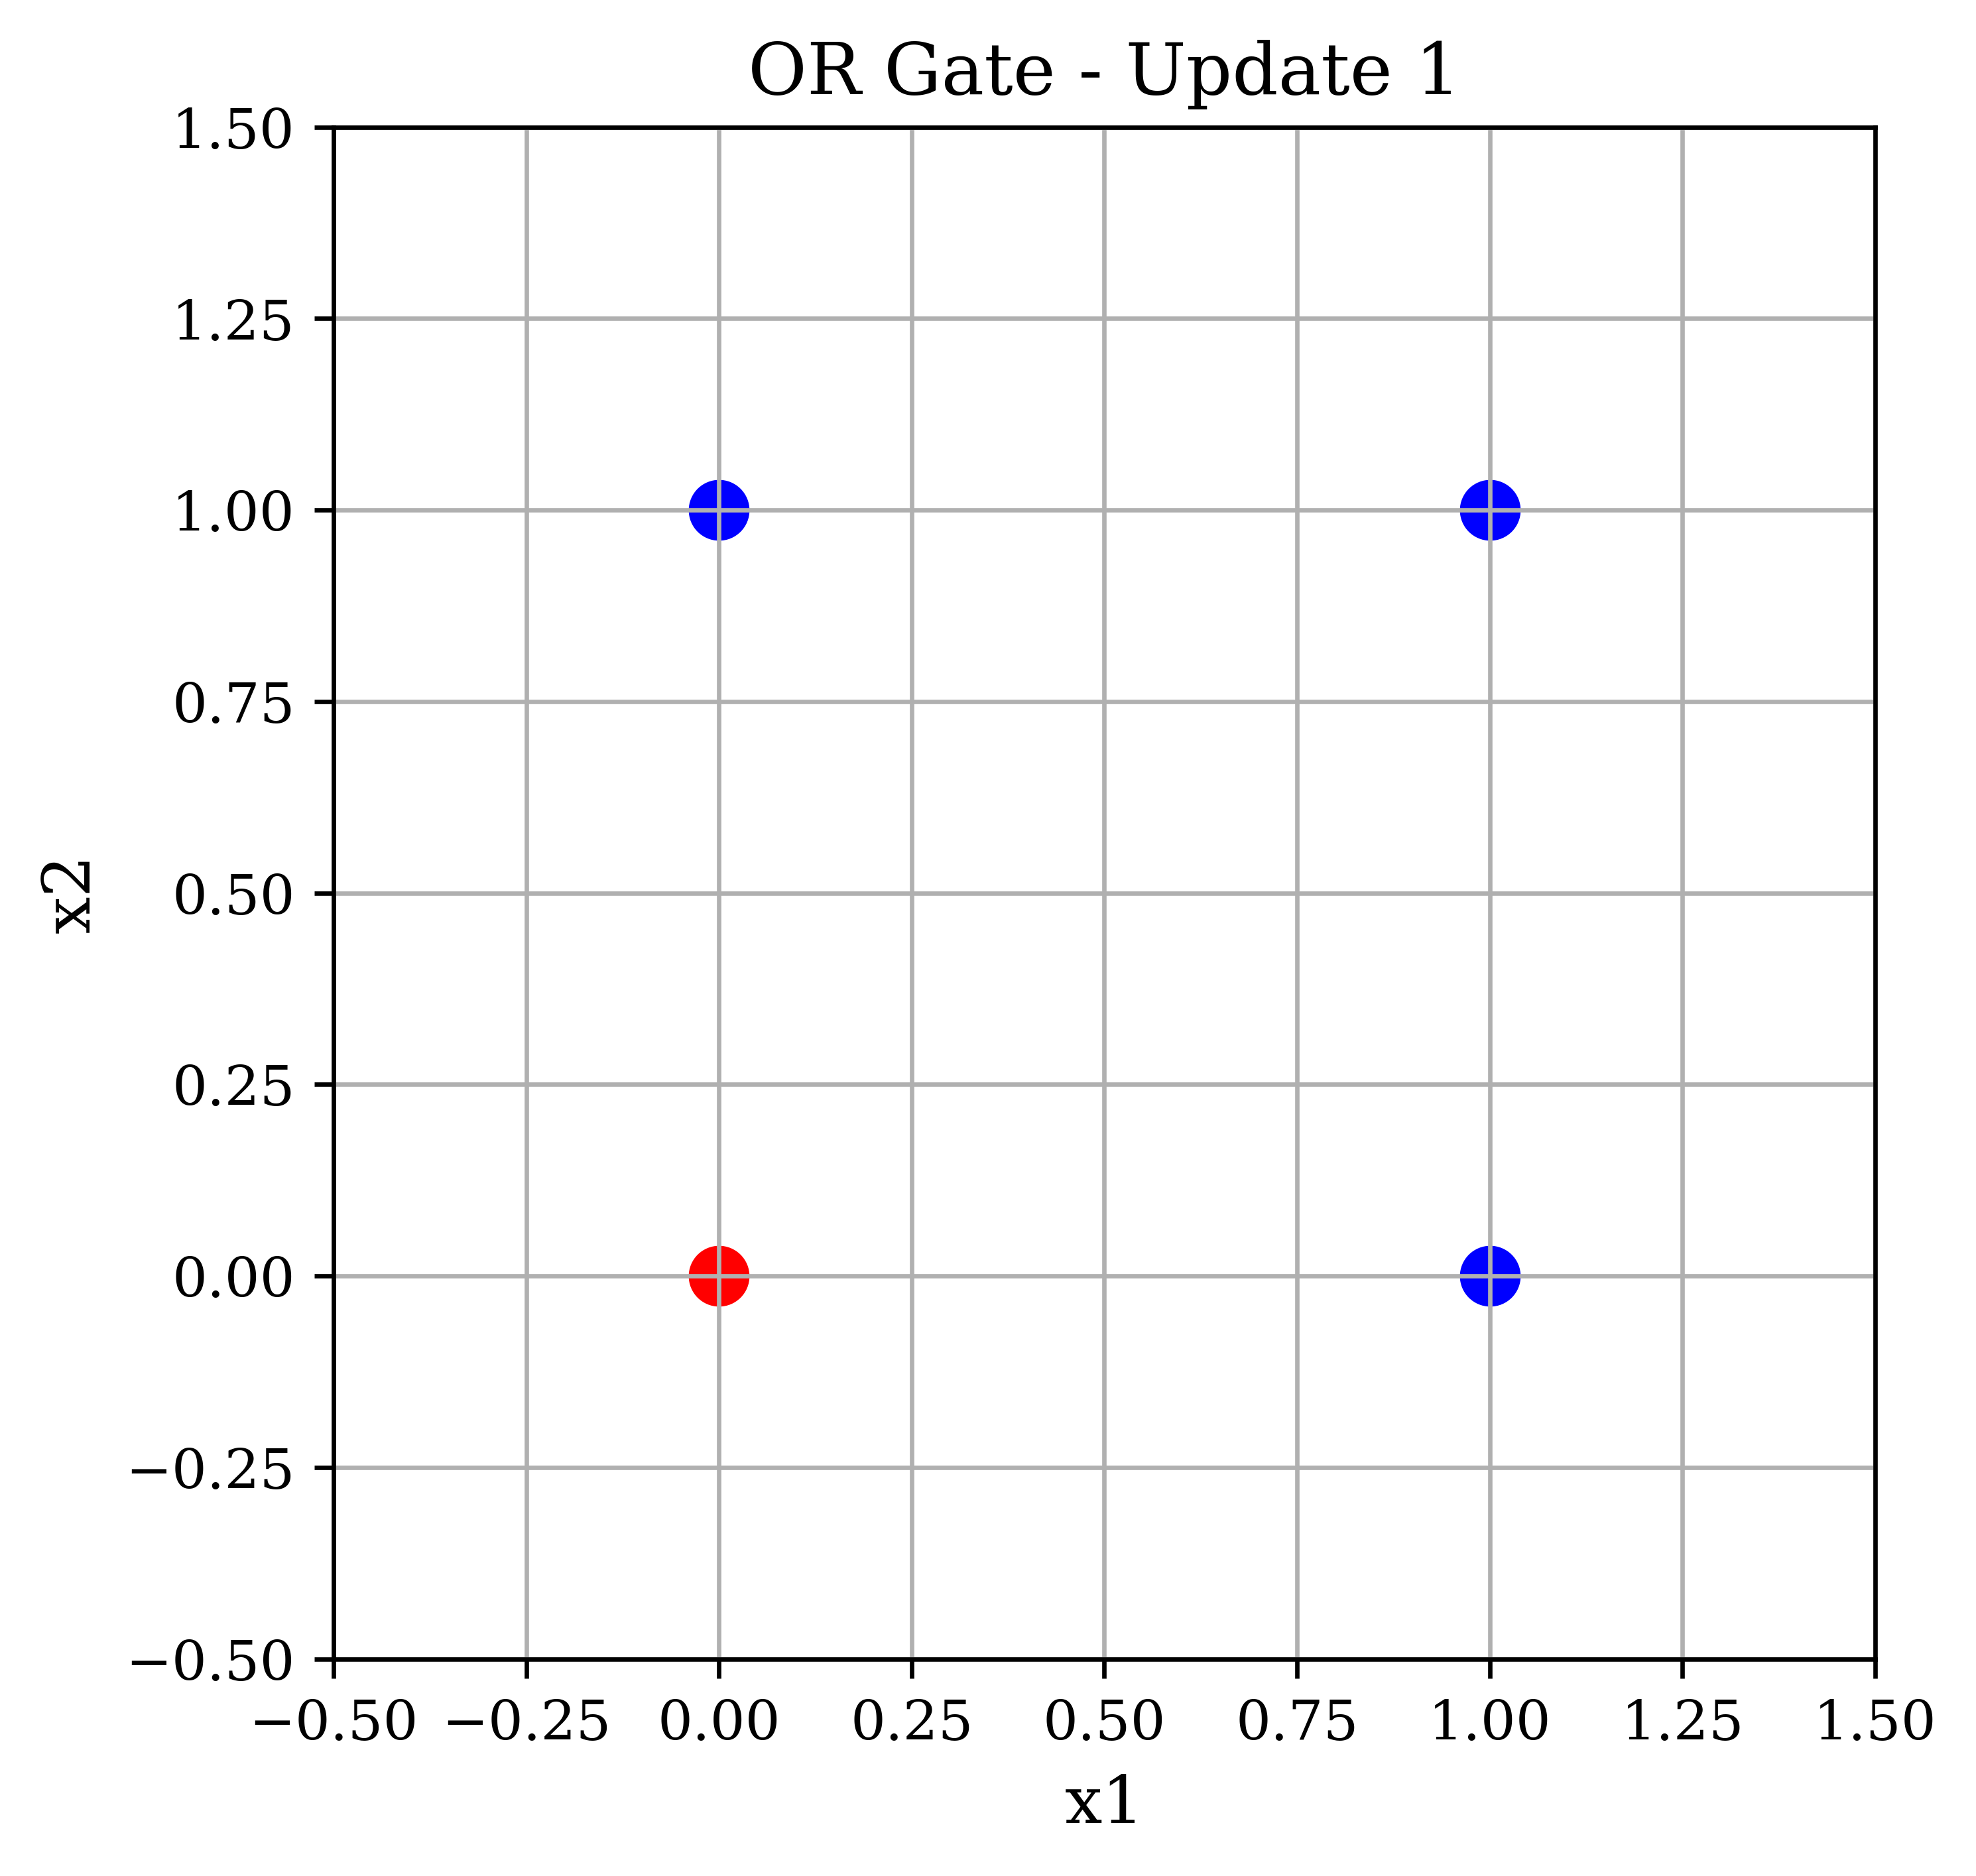

Update 2
Input: [0 1], Target: 1
Weights: [0. 0. 1.]

Saved: /content/plots/or_gate_update_2.eps


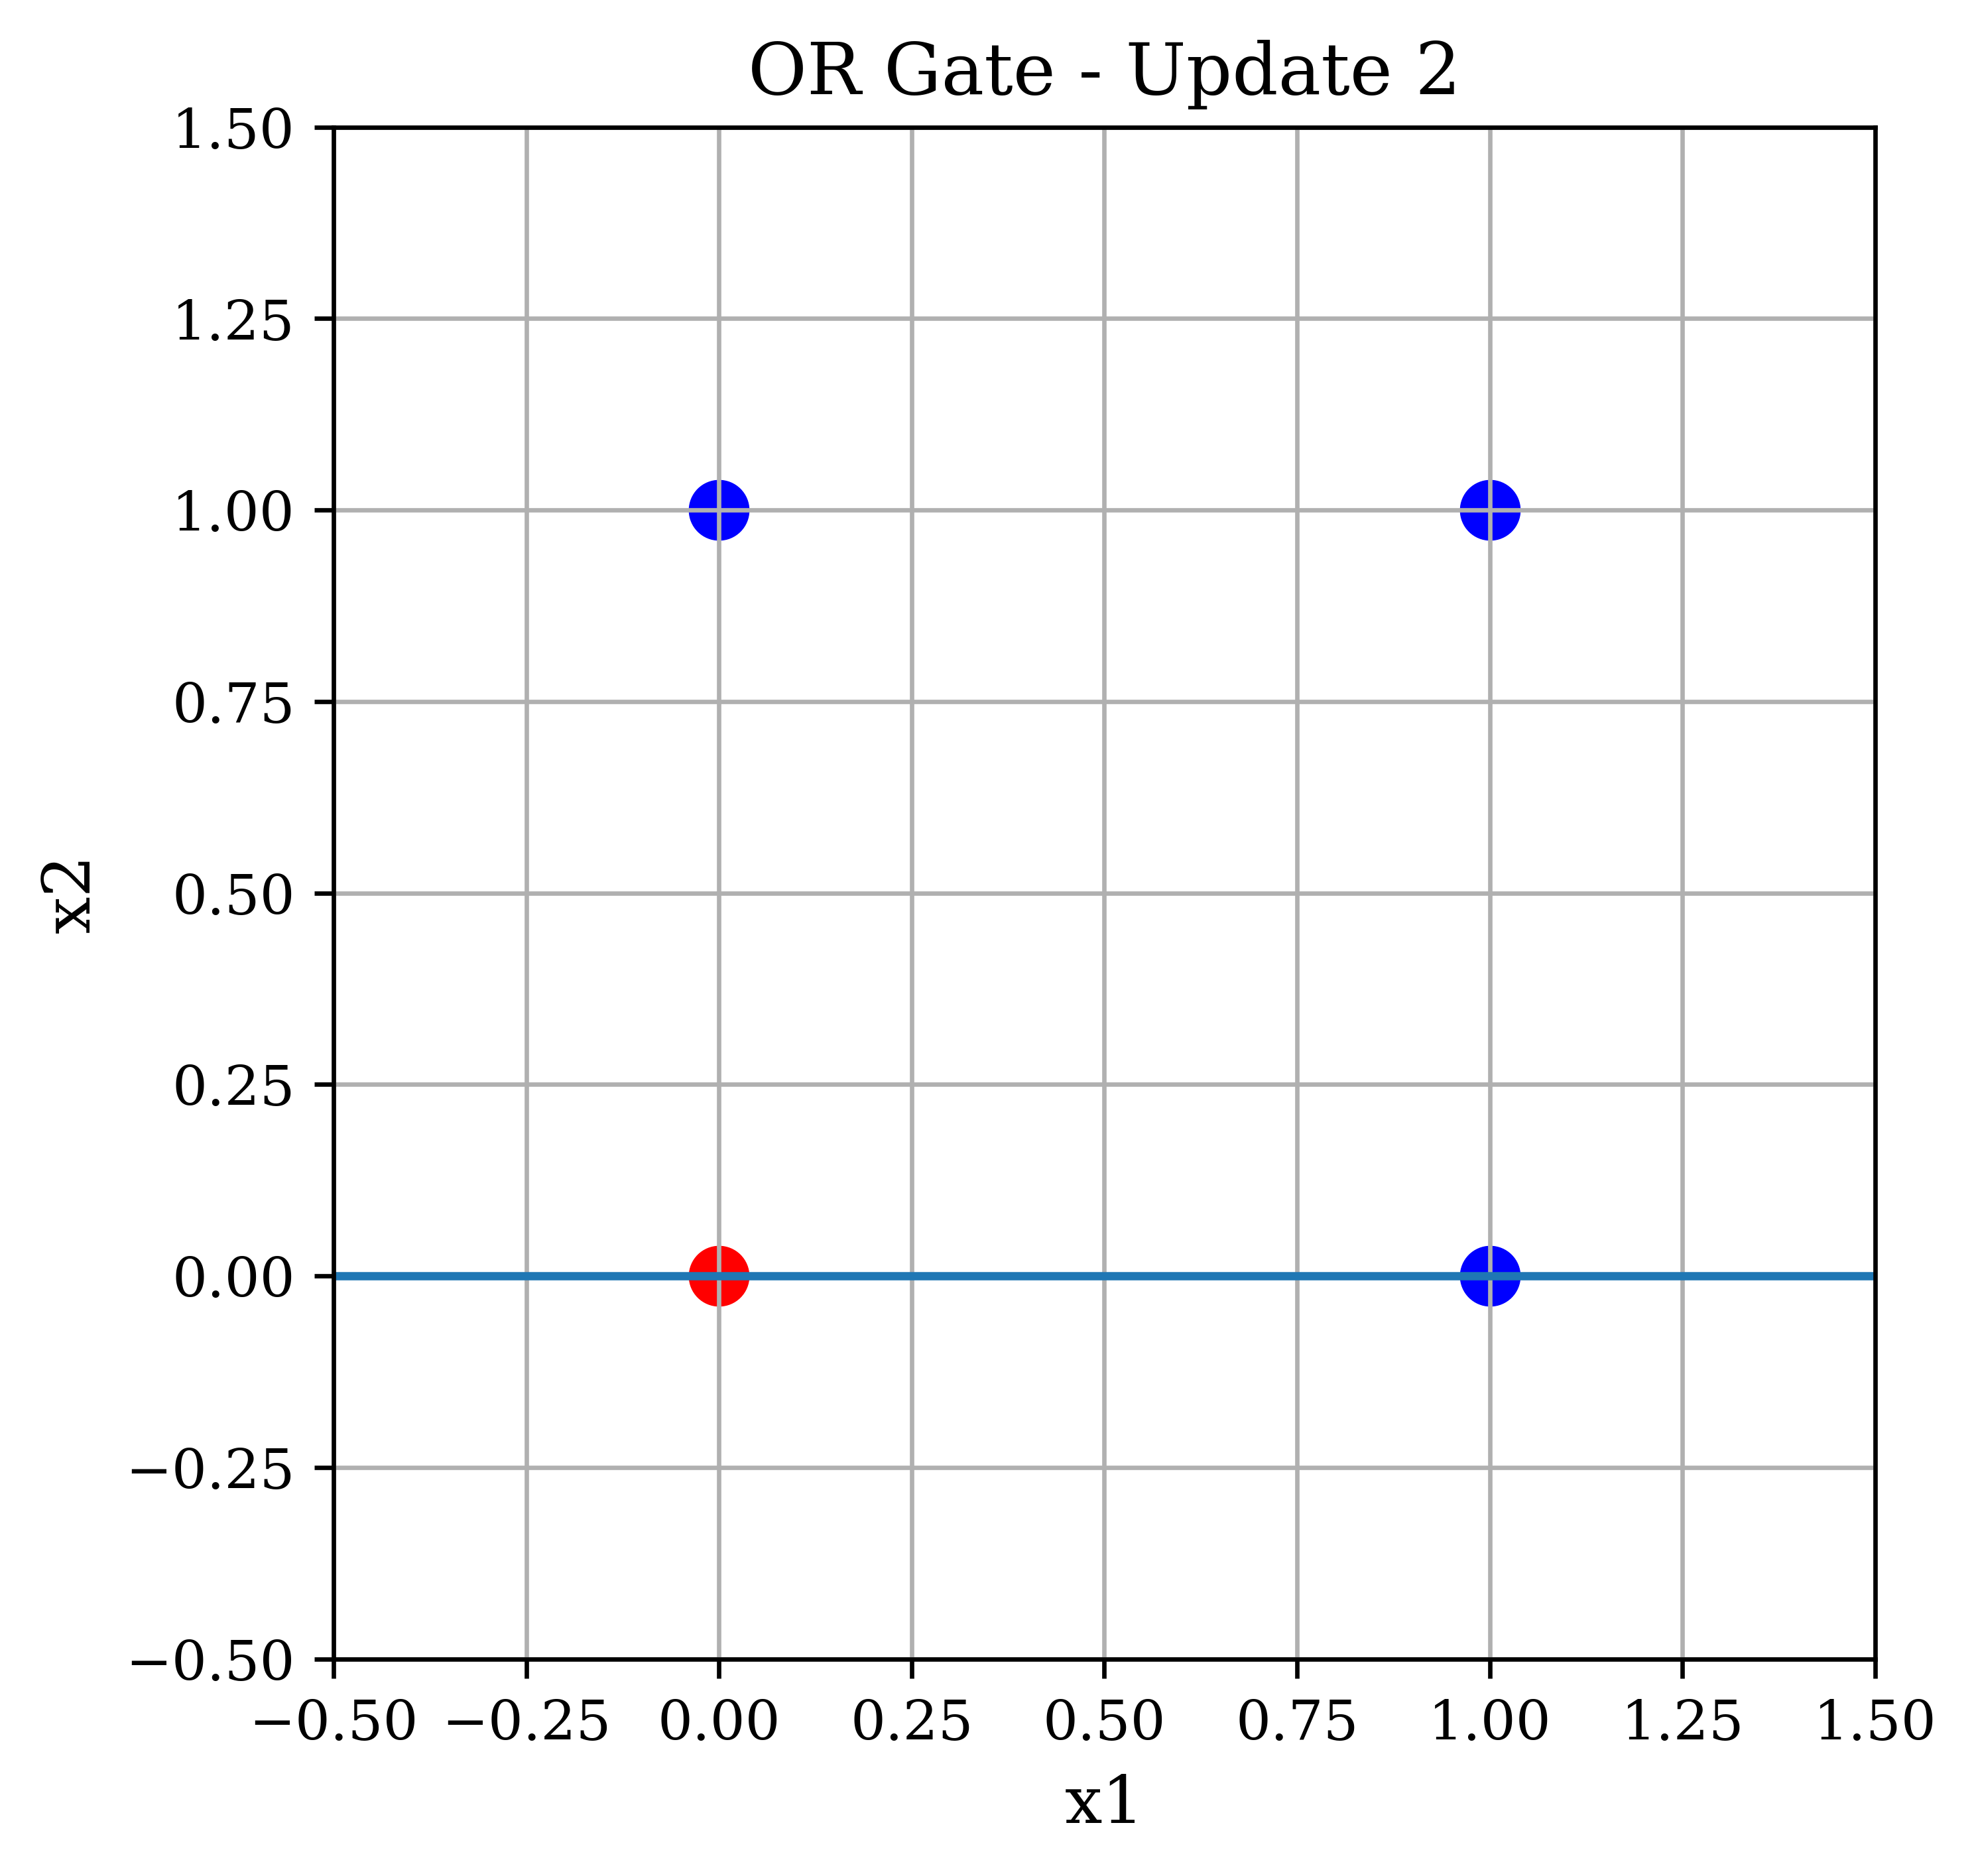

Update 3
Input: [0 0], Target: 0
Weights: [-1.  0.  1.]

Saved: /content/plots/or_gate_update_3.eps


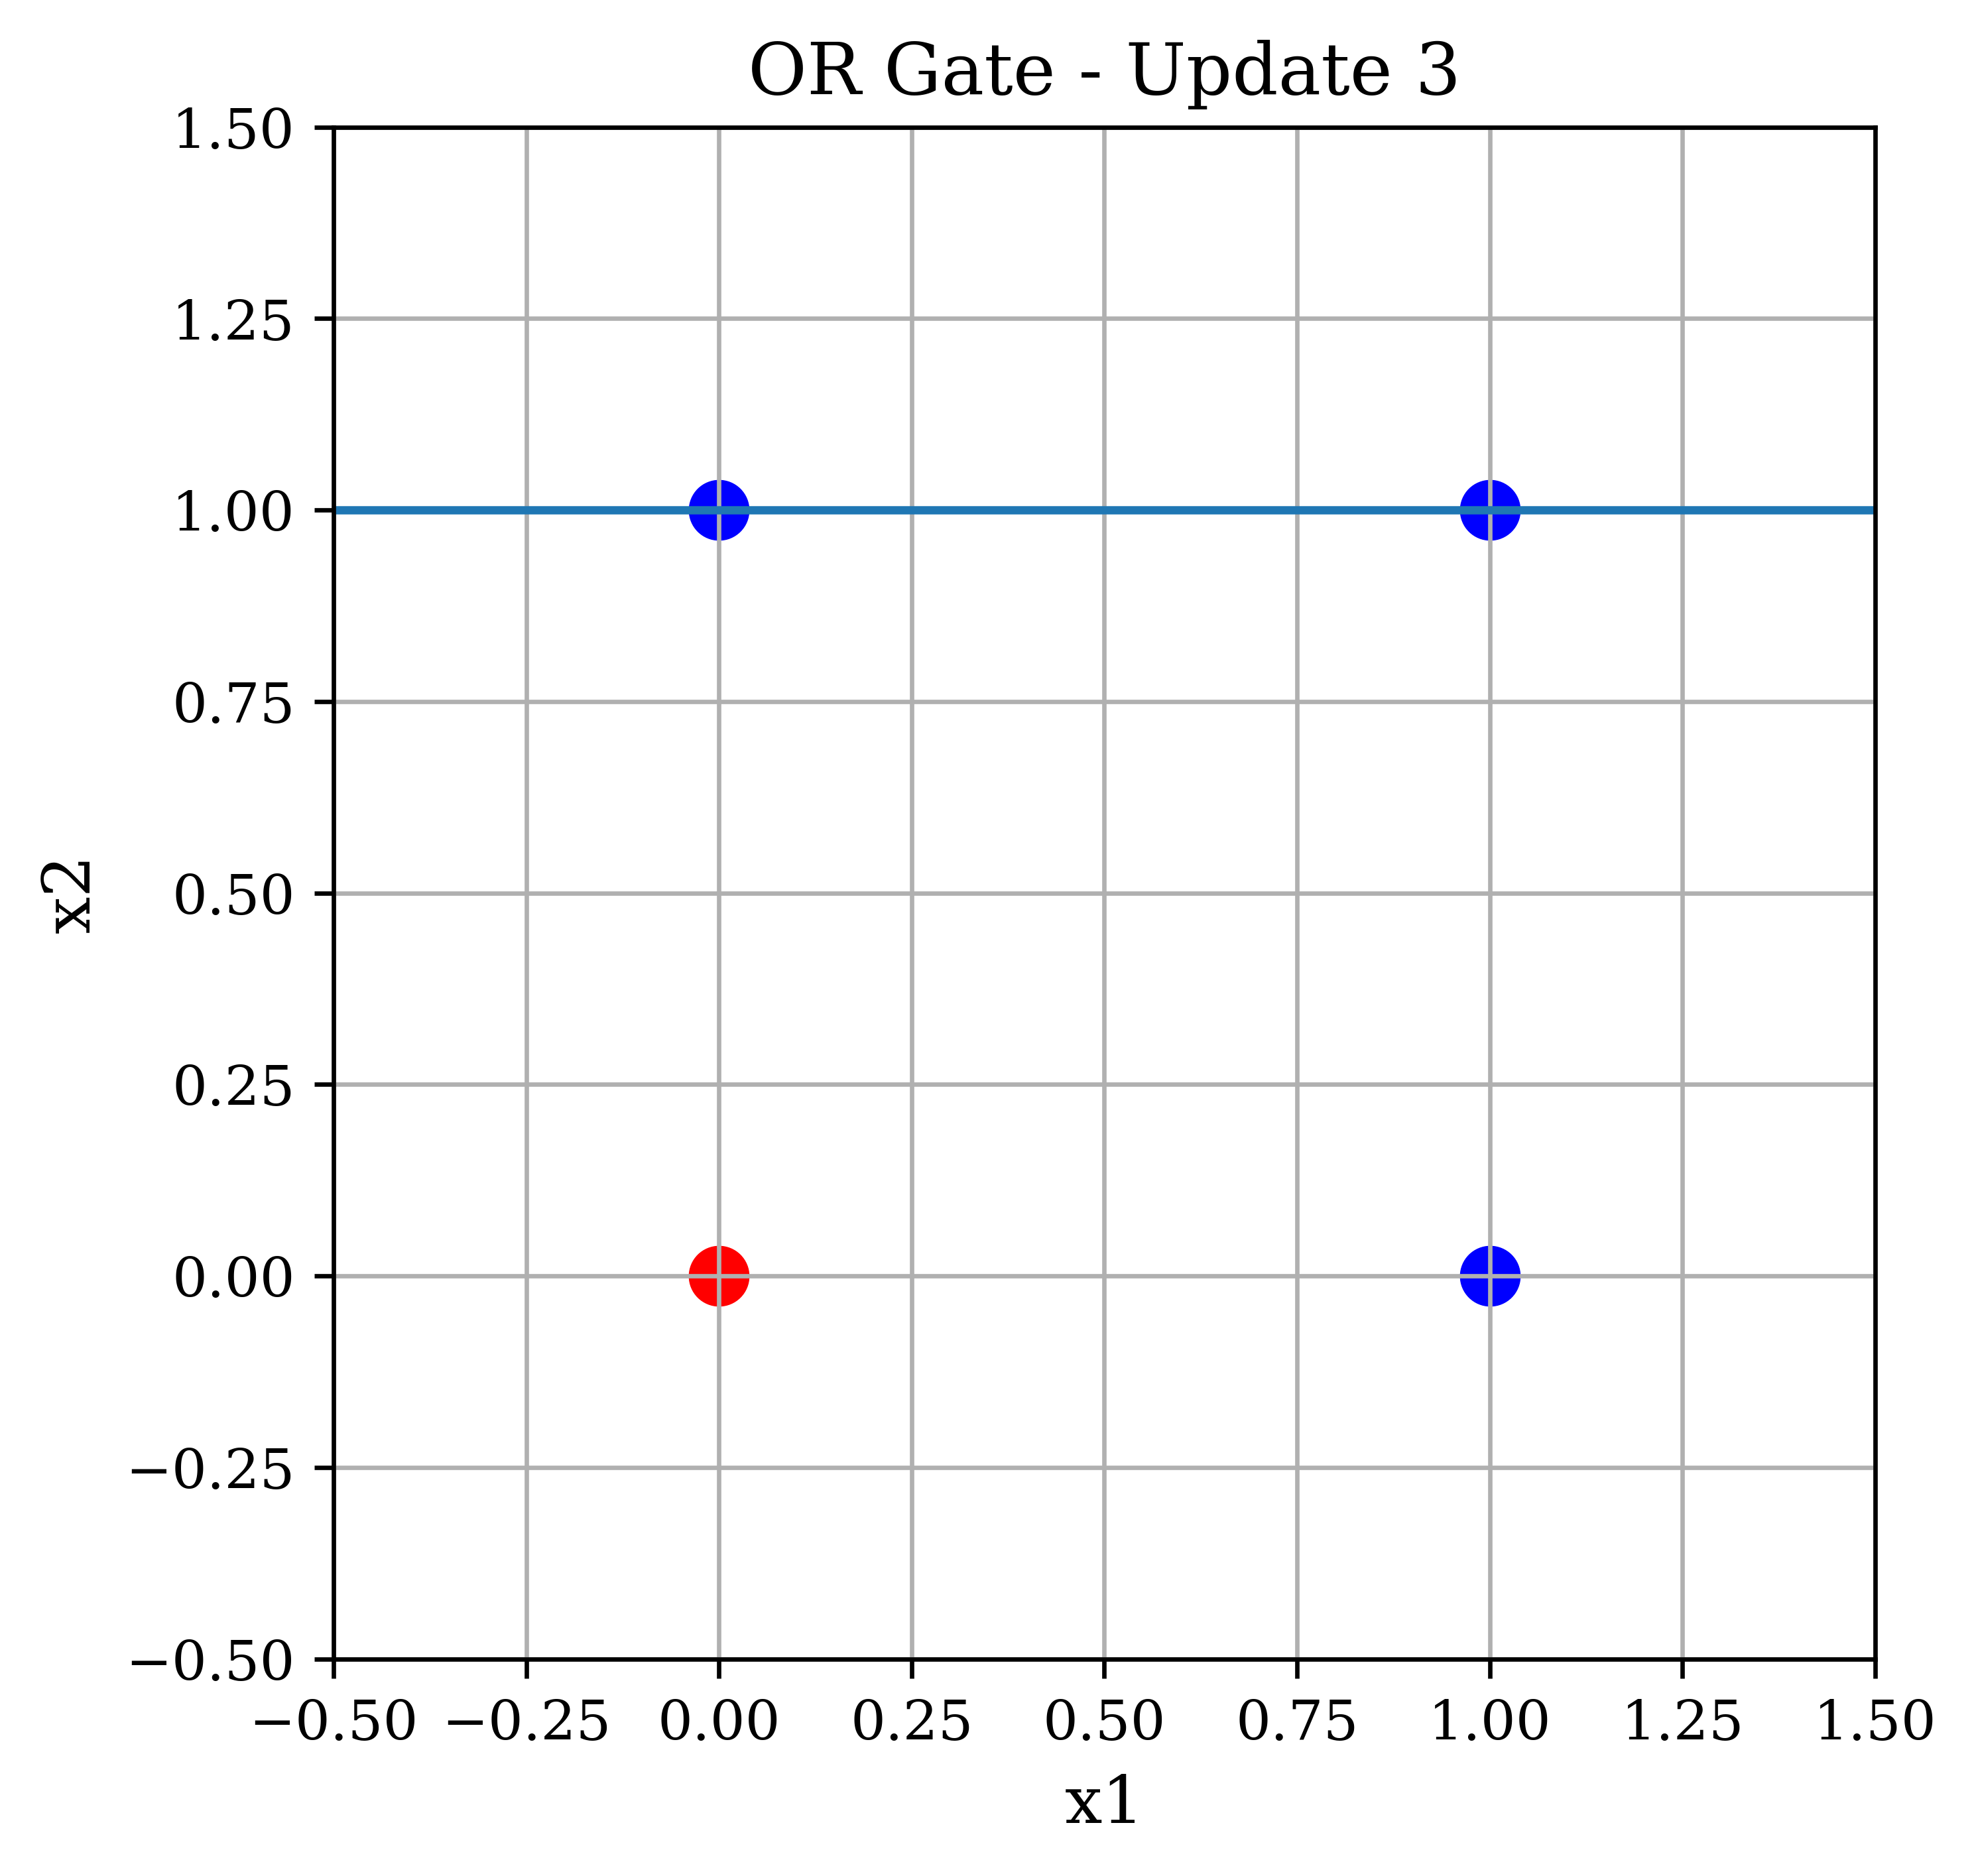

Update 4
Input: [1 0], Target: 1
Weights: [0. 1. 1.]

Saved: /content/plots/or_gate_update_4.eps


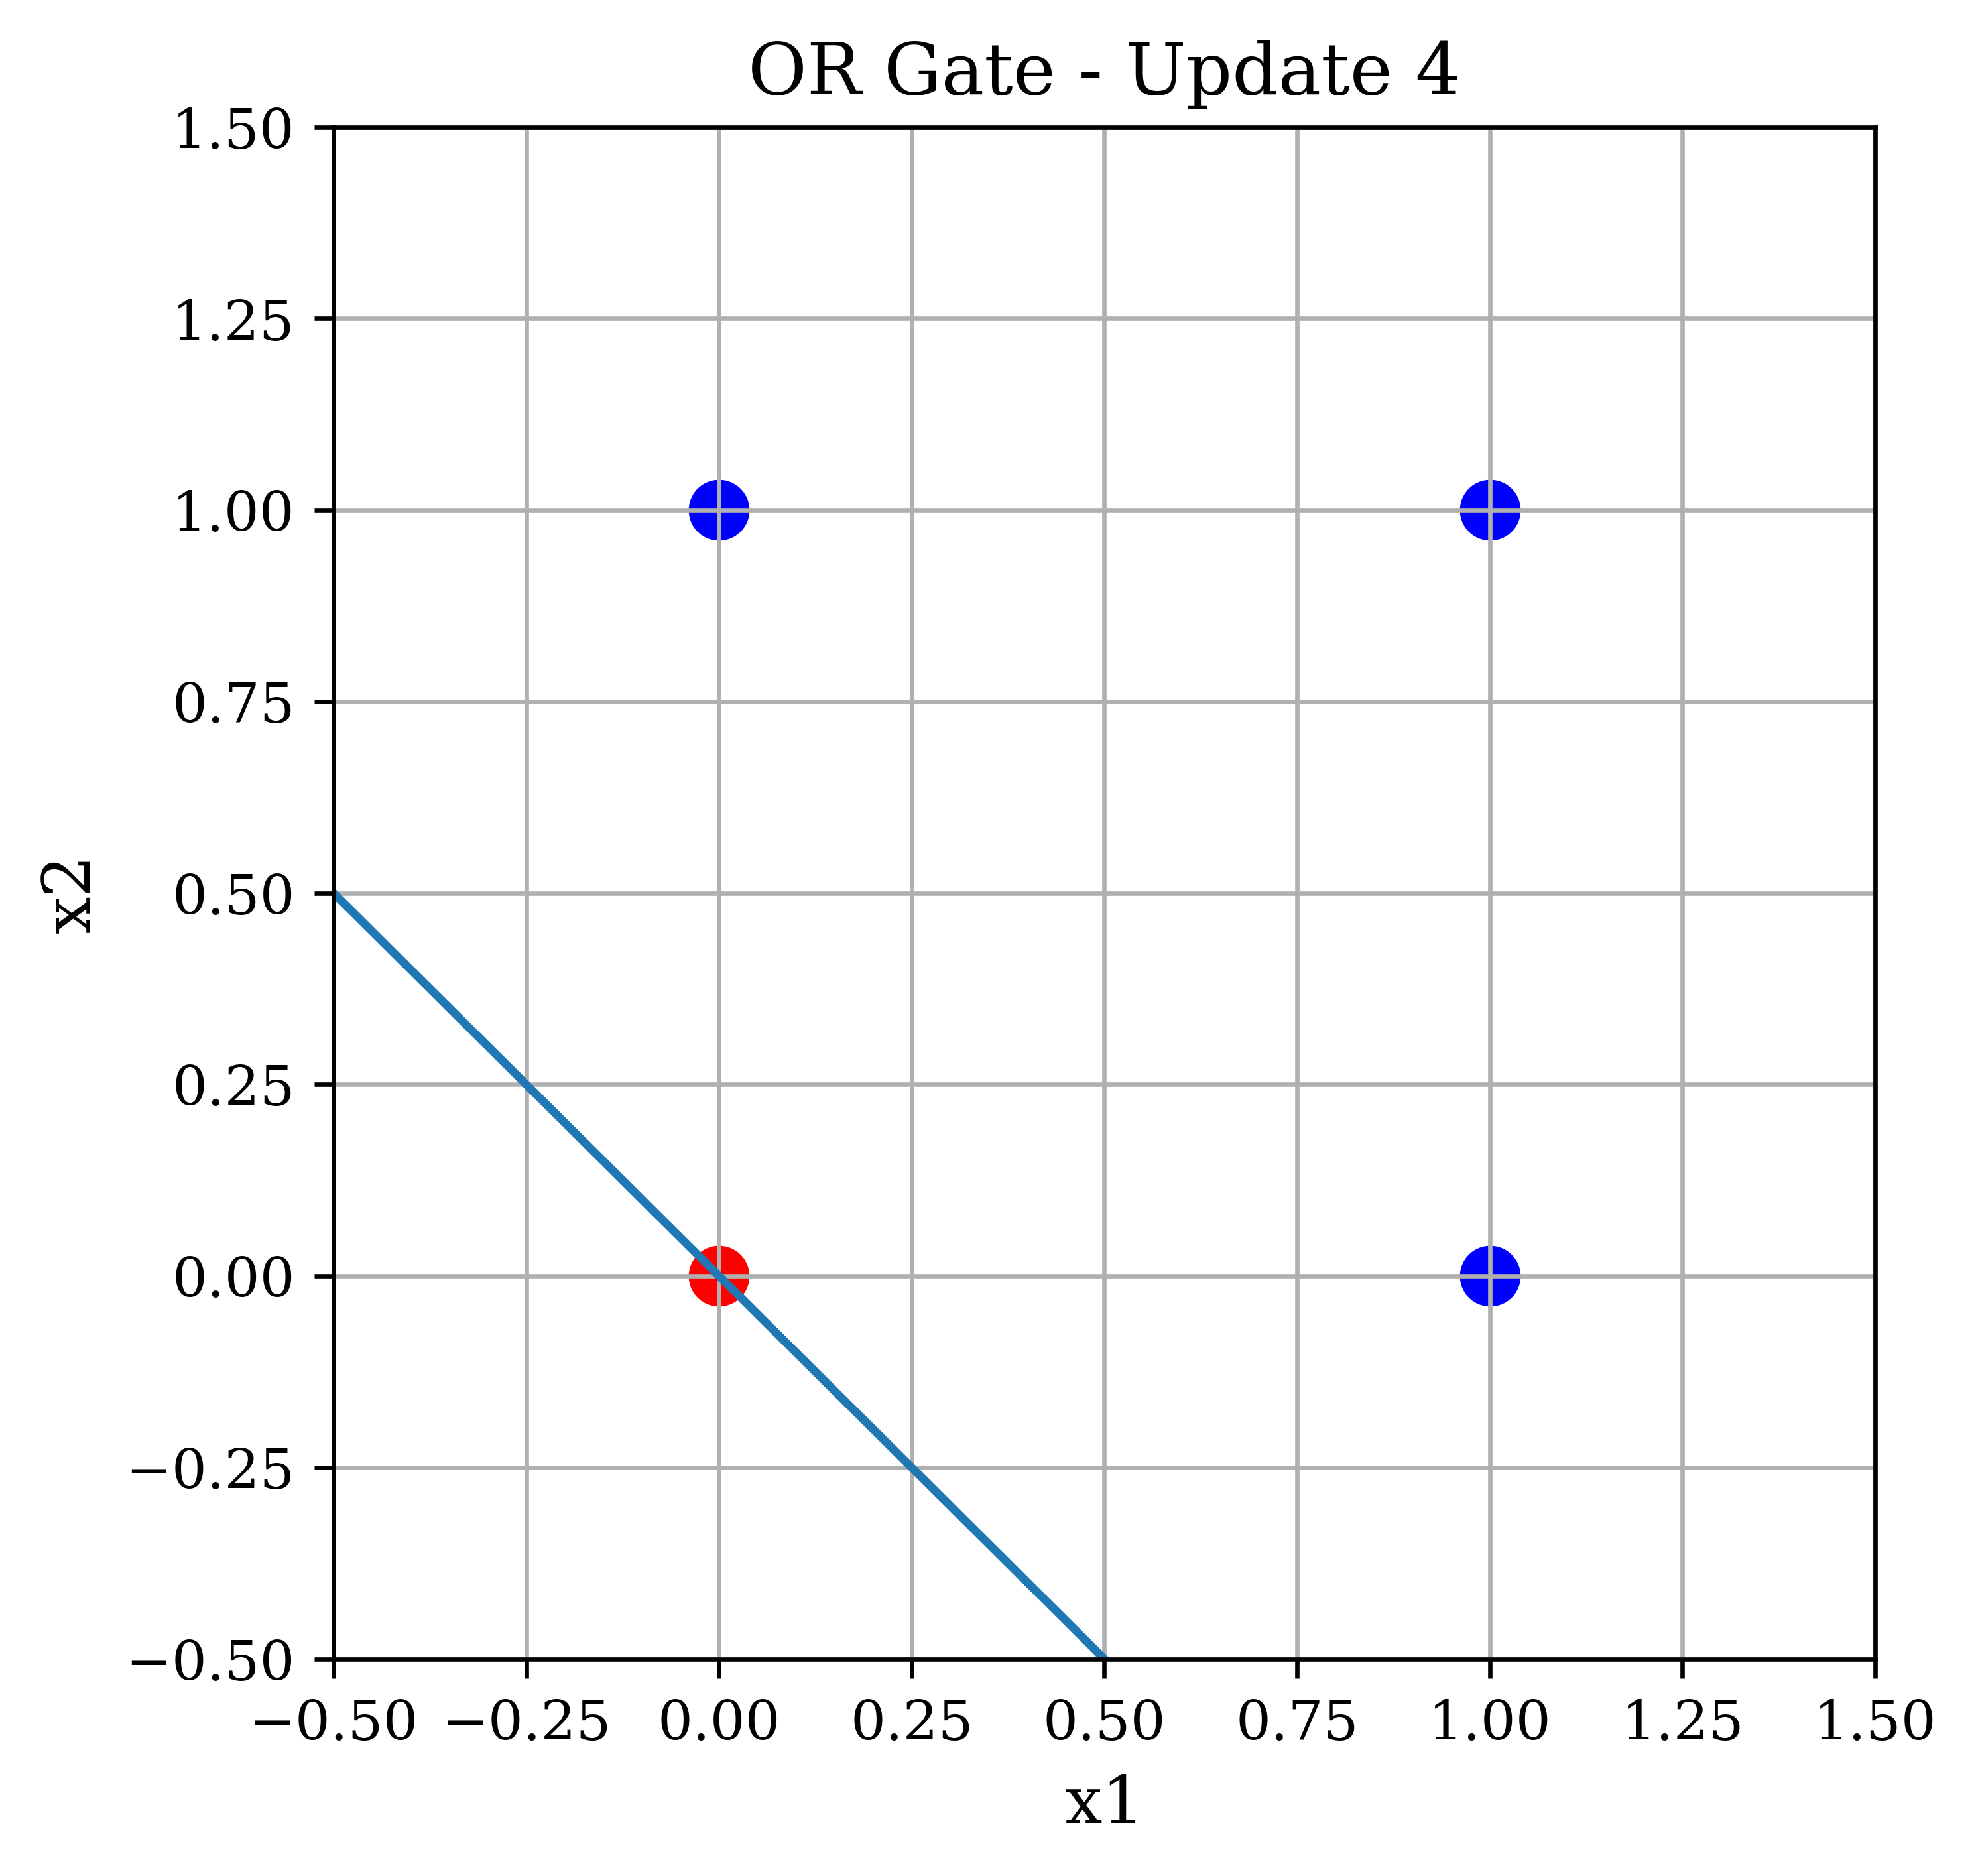

Update 5
Input: [0 0], Target: 0
Weights: [-1.  1.  1.]

Saved: /content/plots/or_gate_update_5.eps


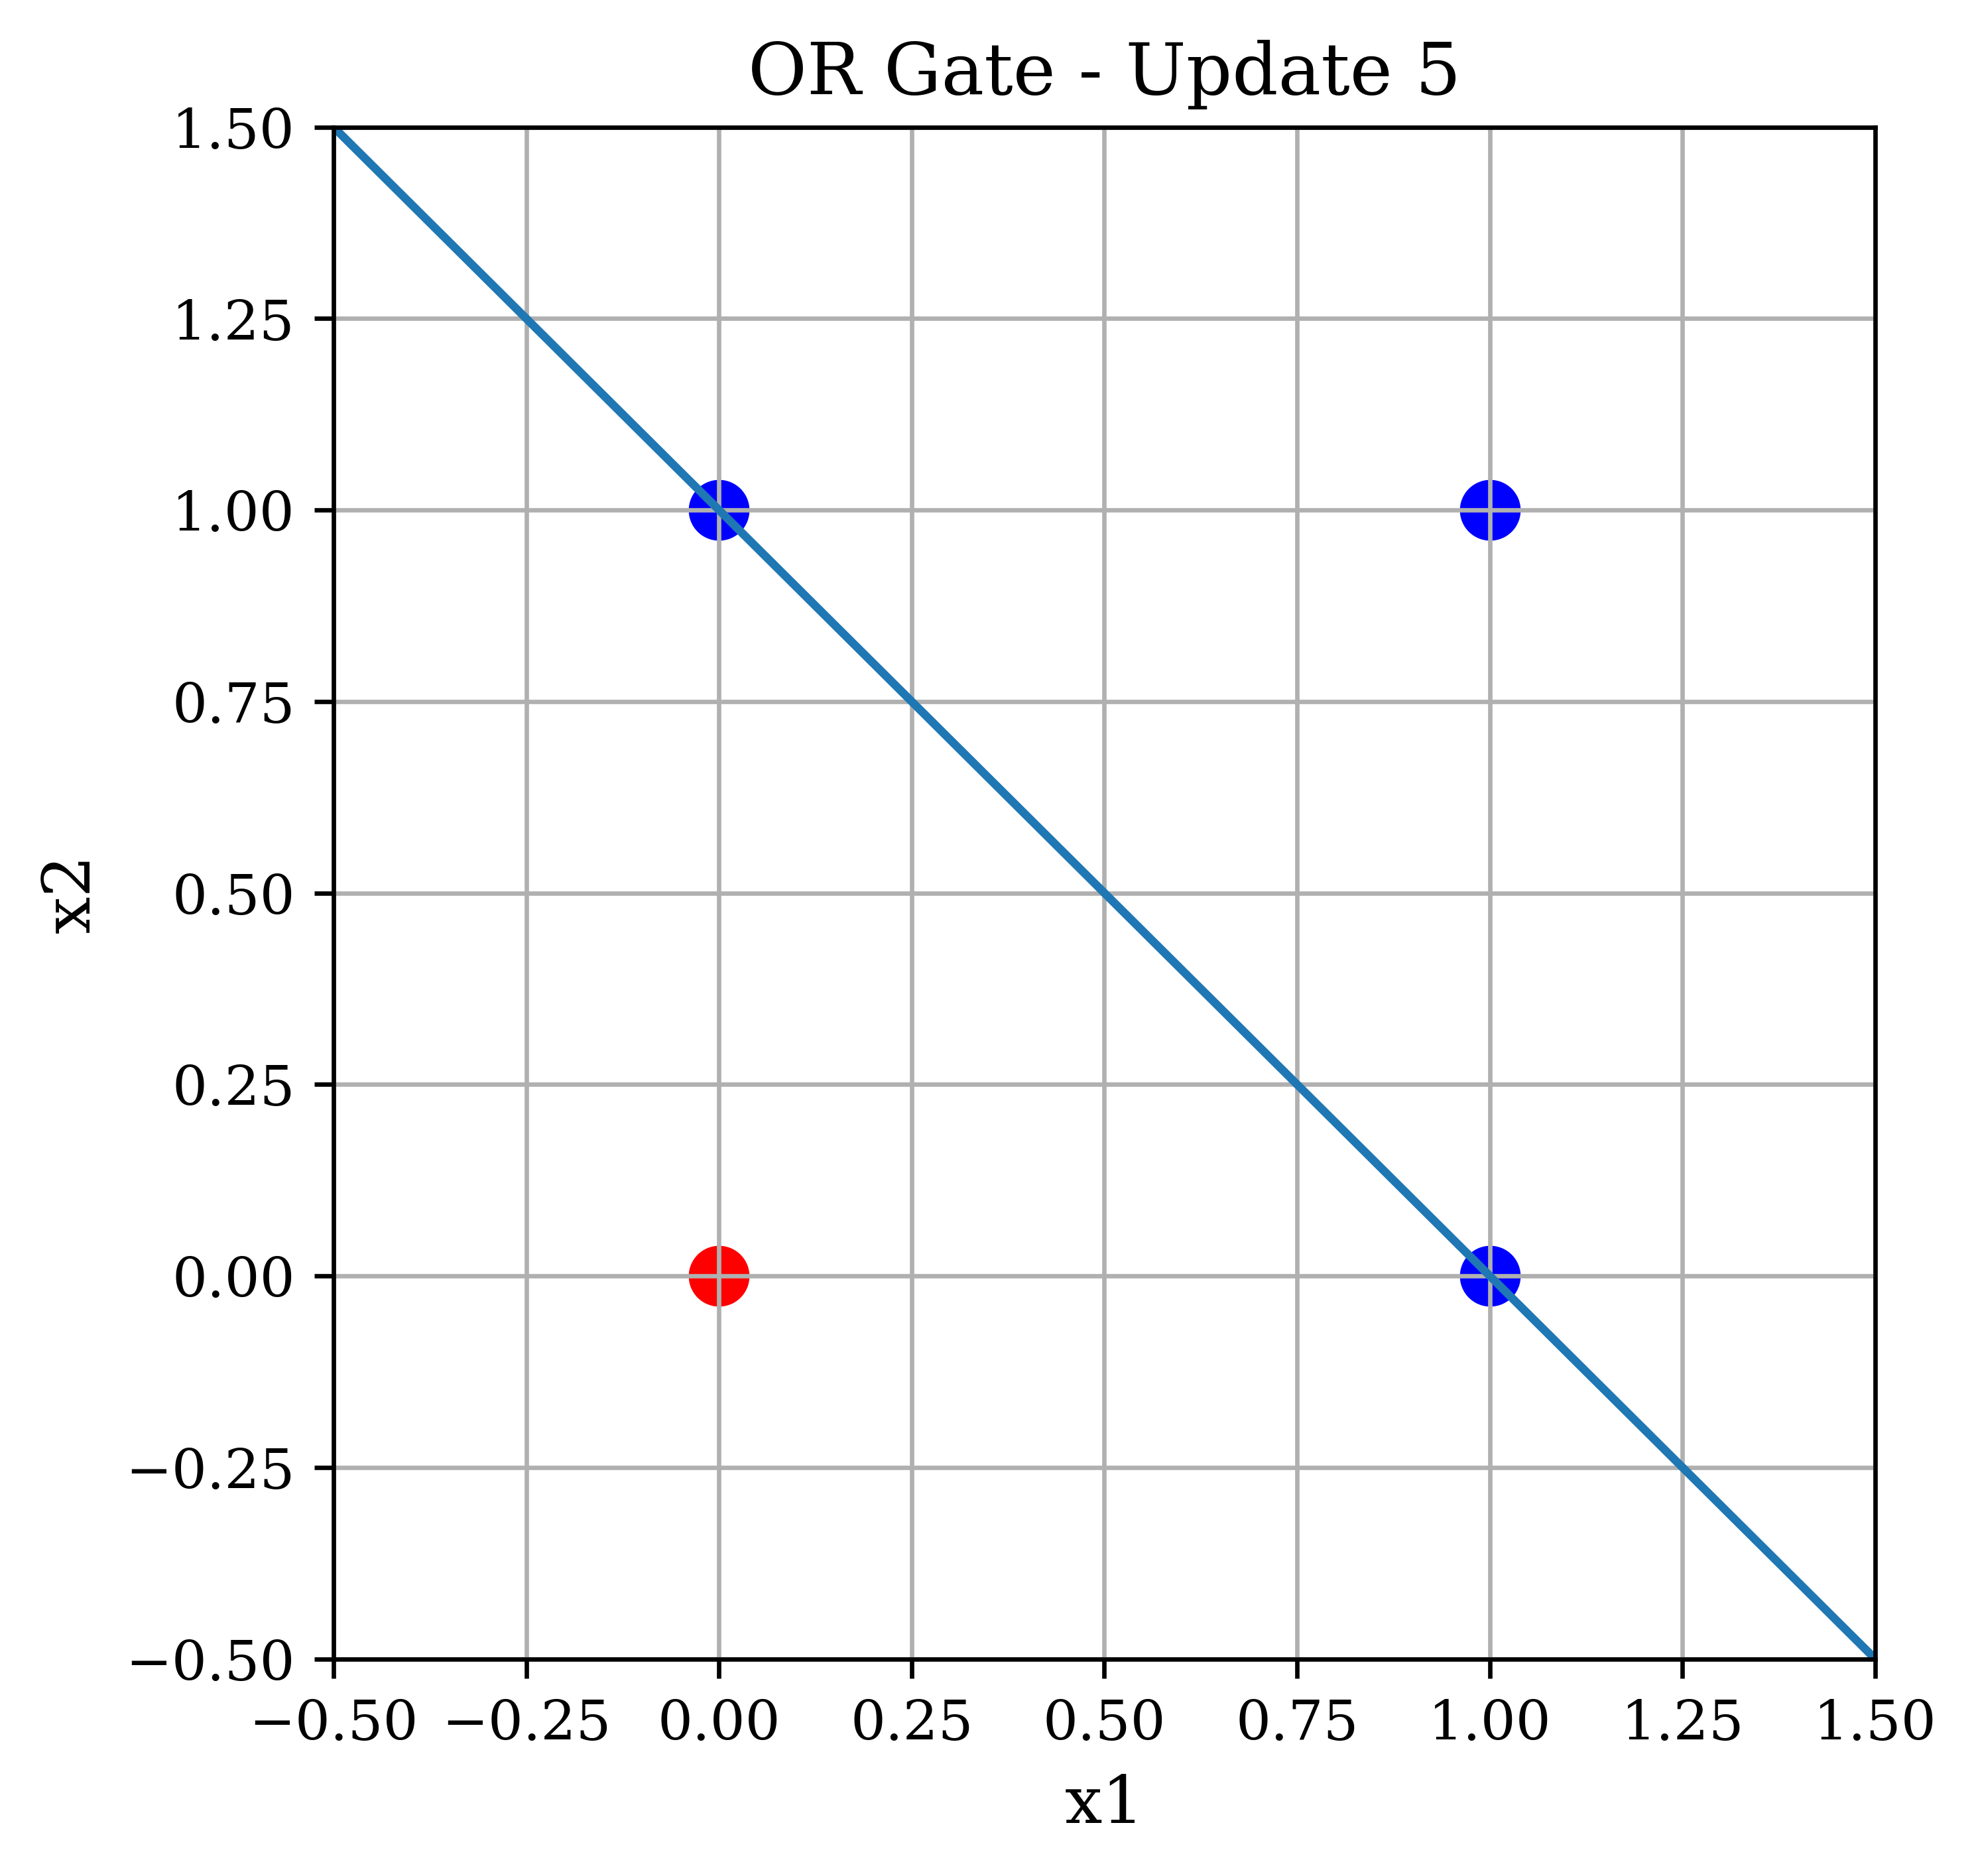

Converged after 4 epochs.

NOT GATE
Update 1
Input: [1 1], Target: 0
Weights: [-1. -1. -1.]

Saved: /content/plots/not_gate_update_1.eps


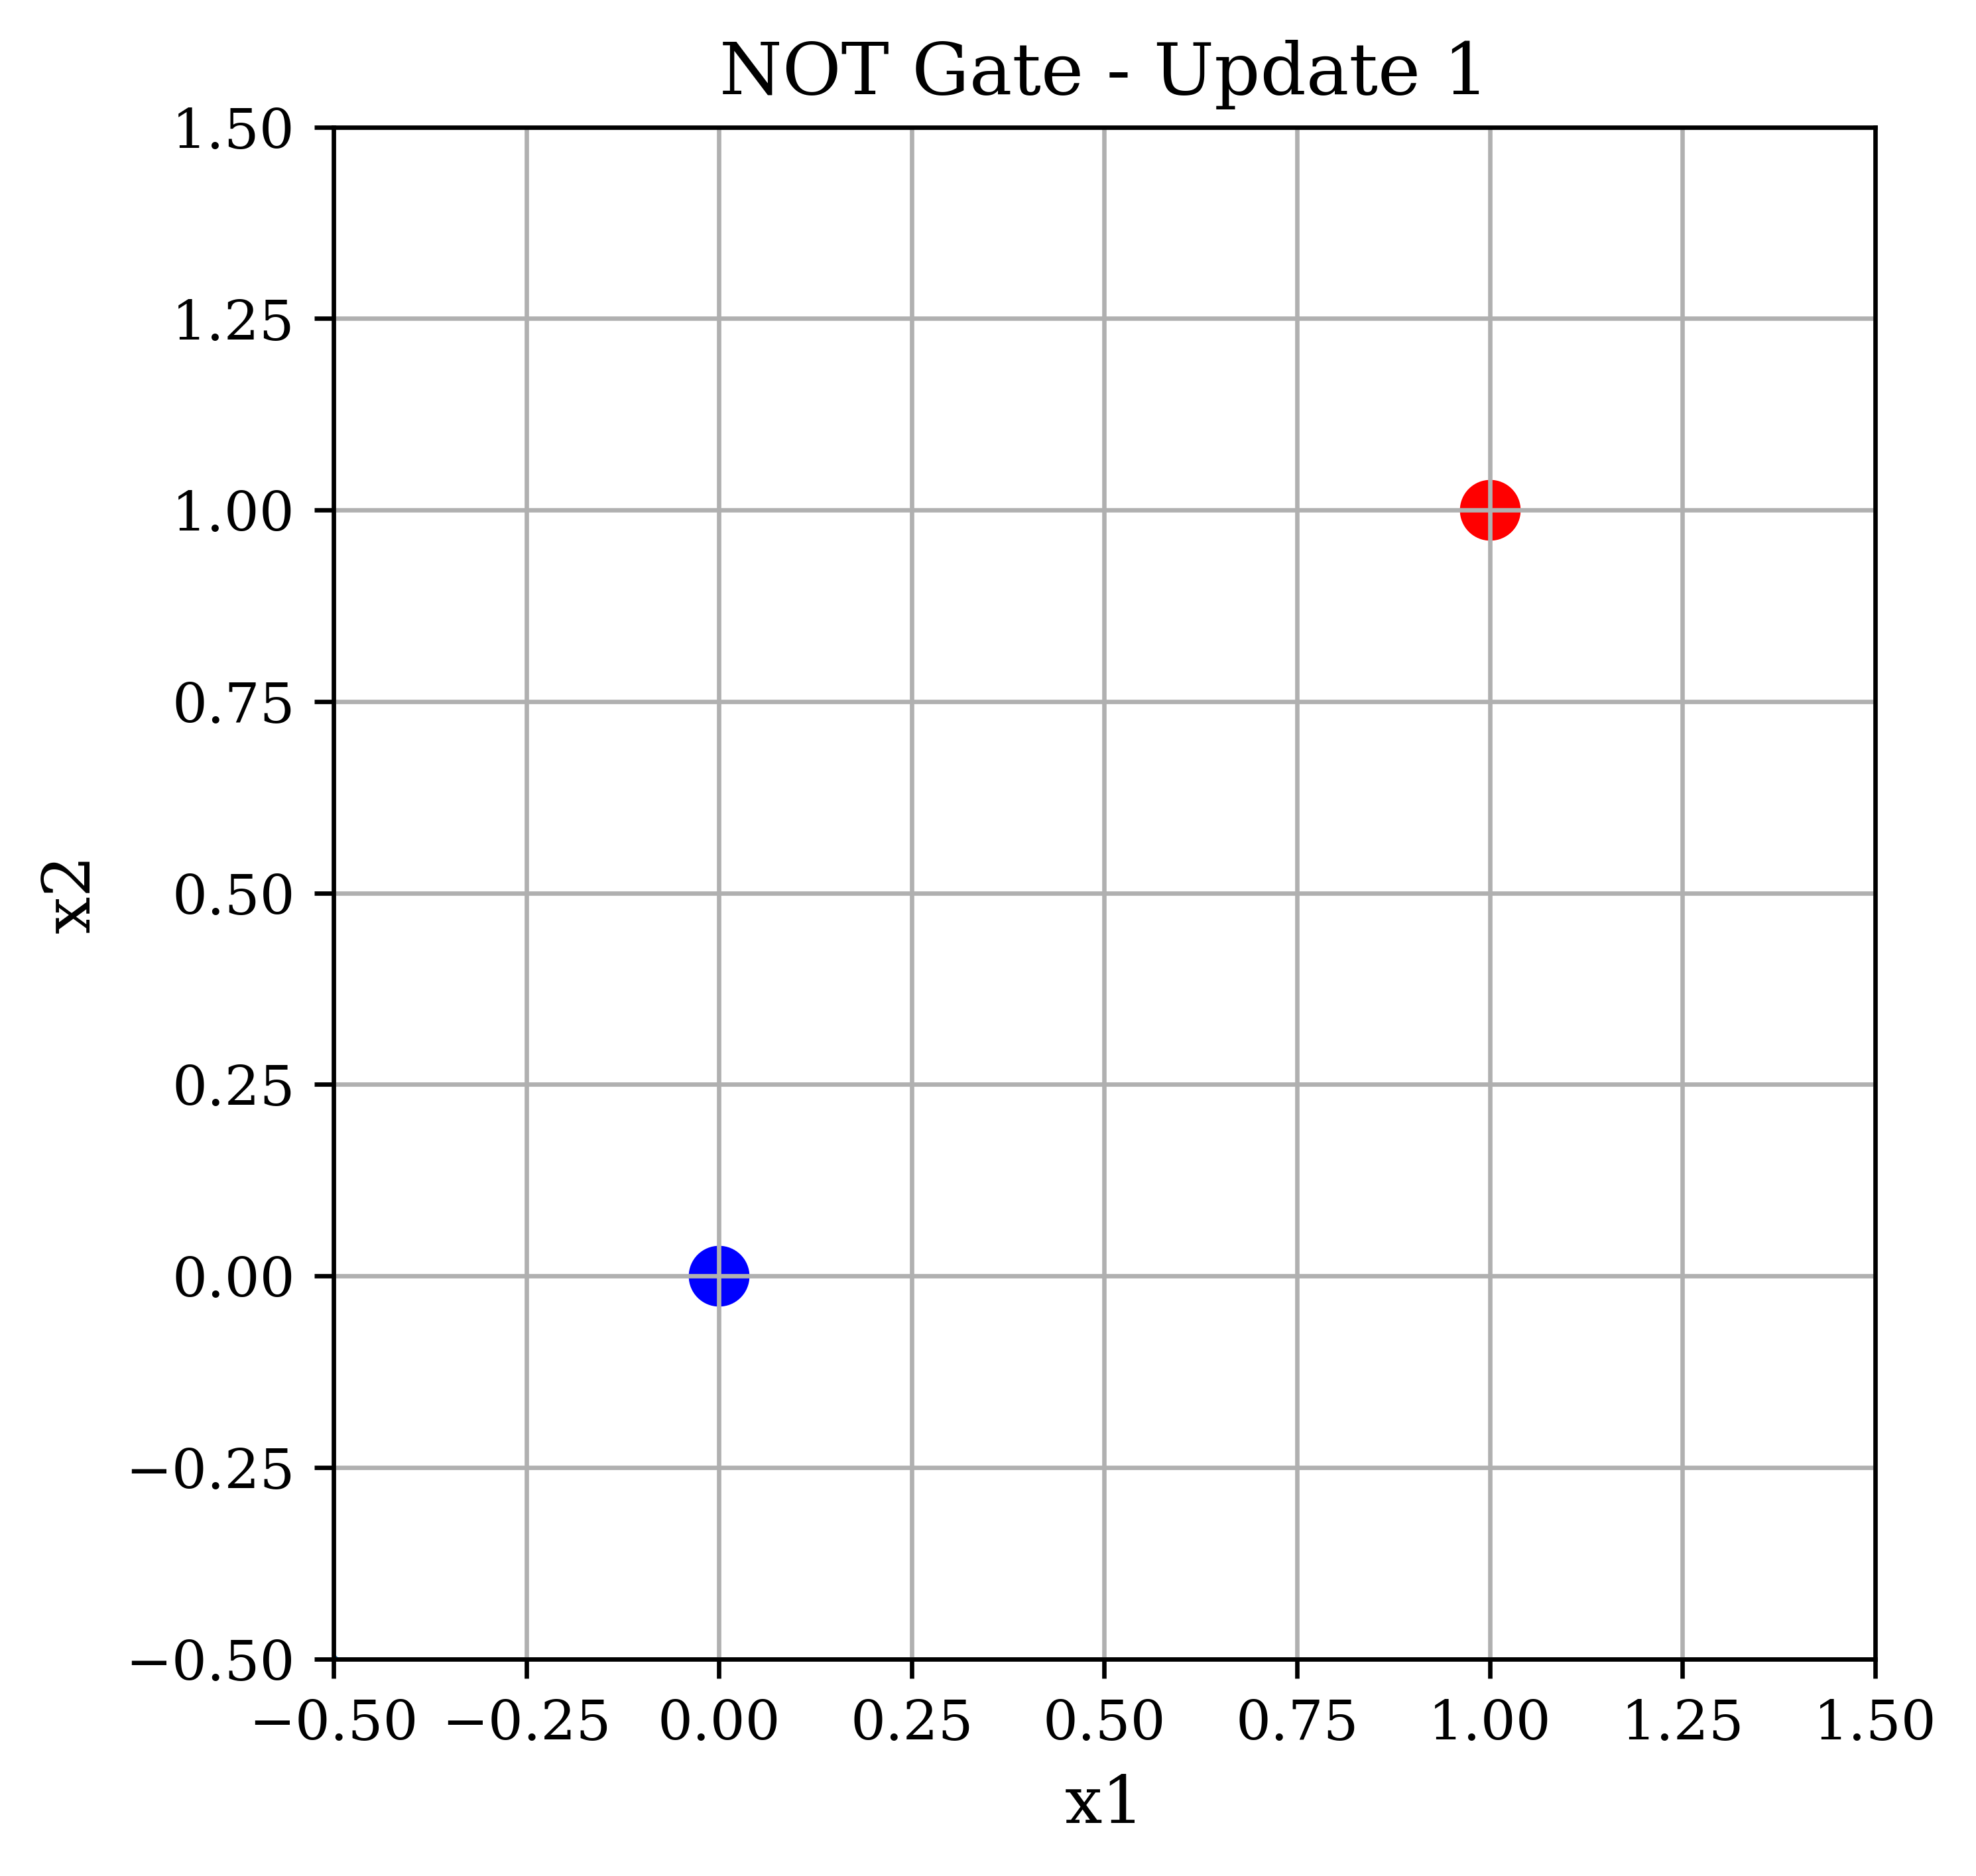

Update 2
Input: [0 0], Target: 1
Weights: [ 0. -1. -1.]

Saved: /content/plots/not_gate_update_2.eps


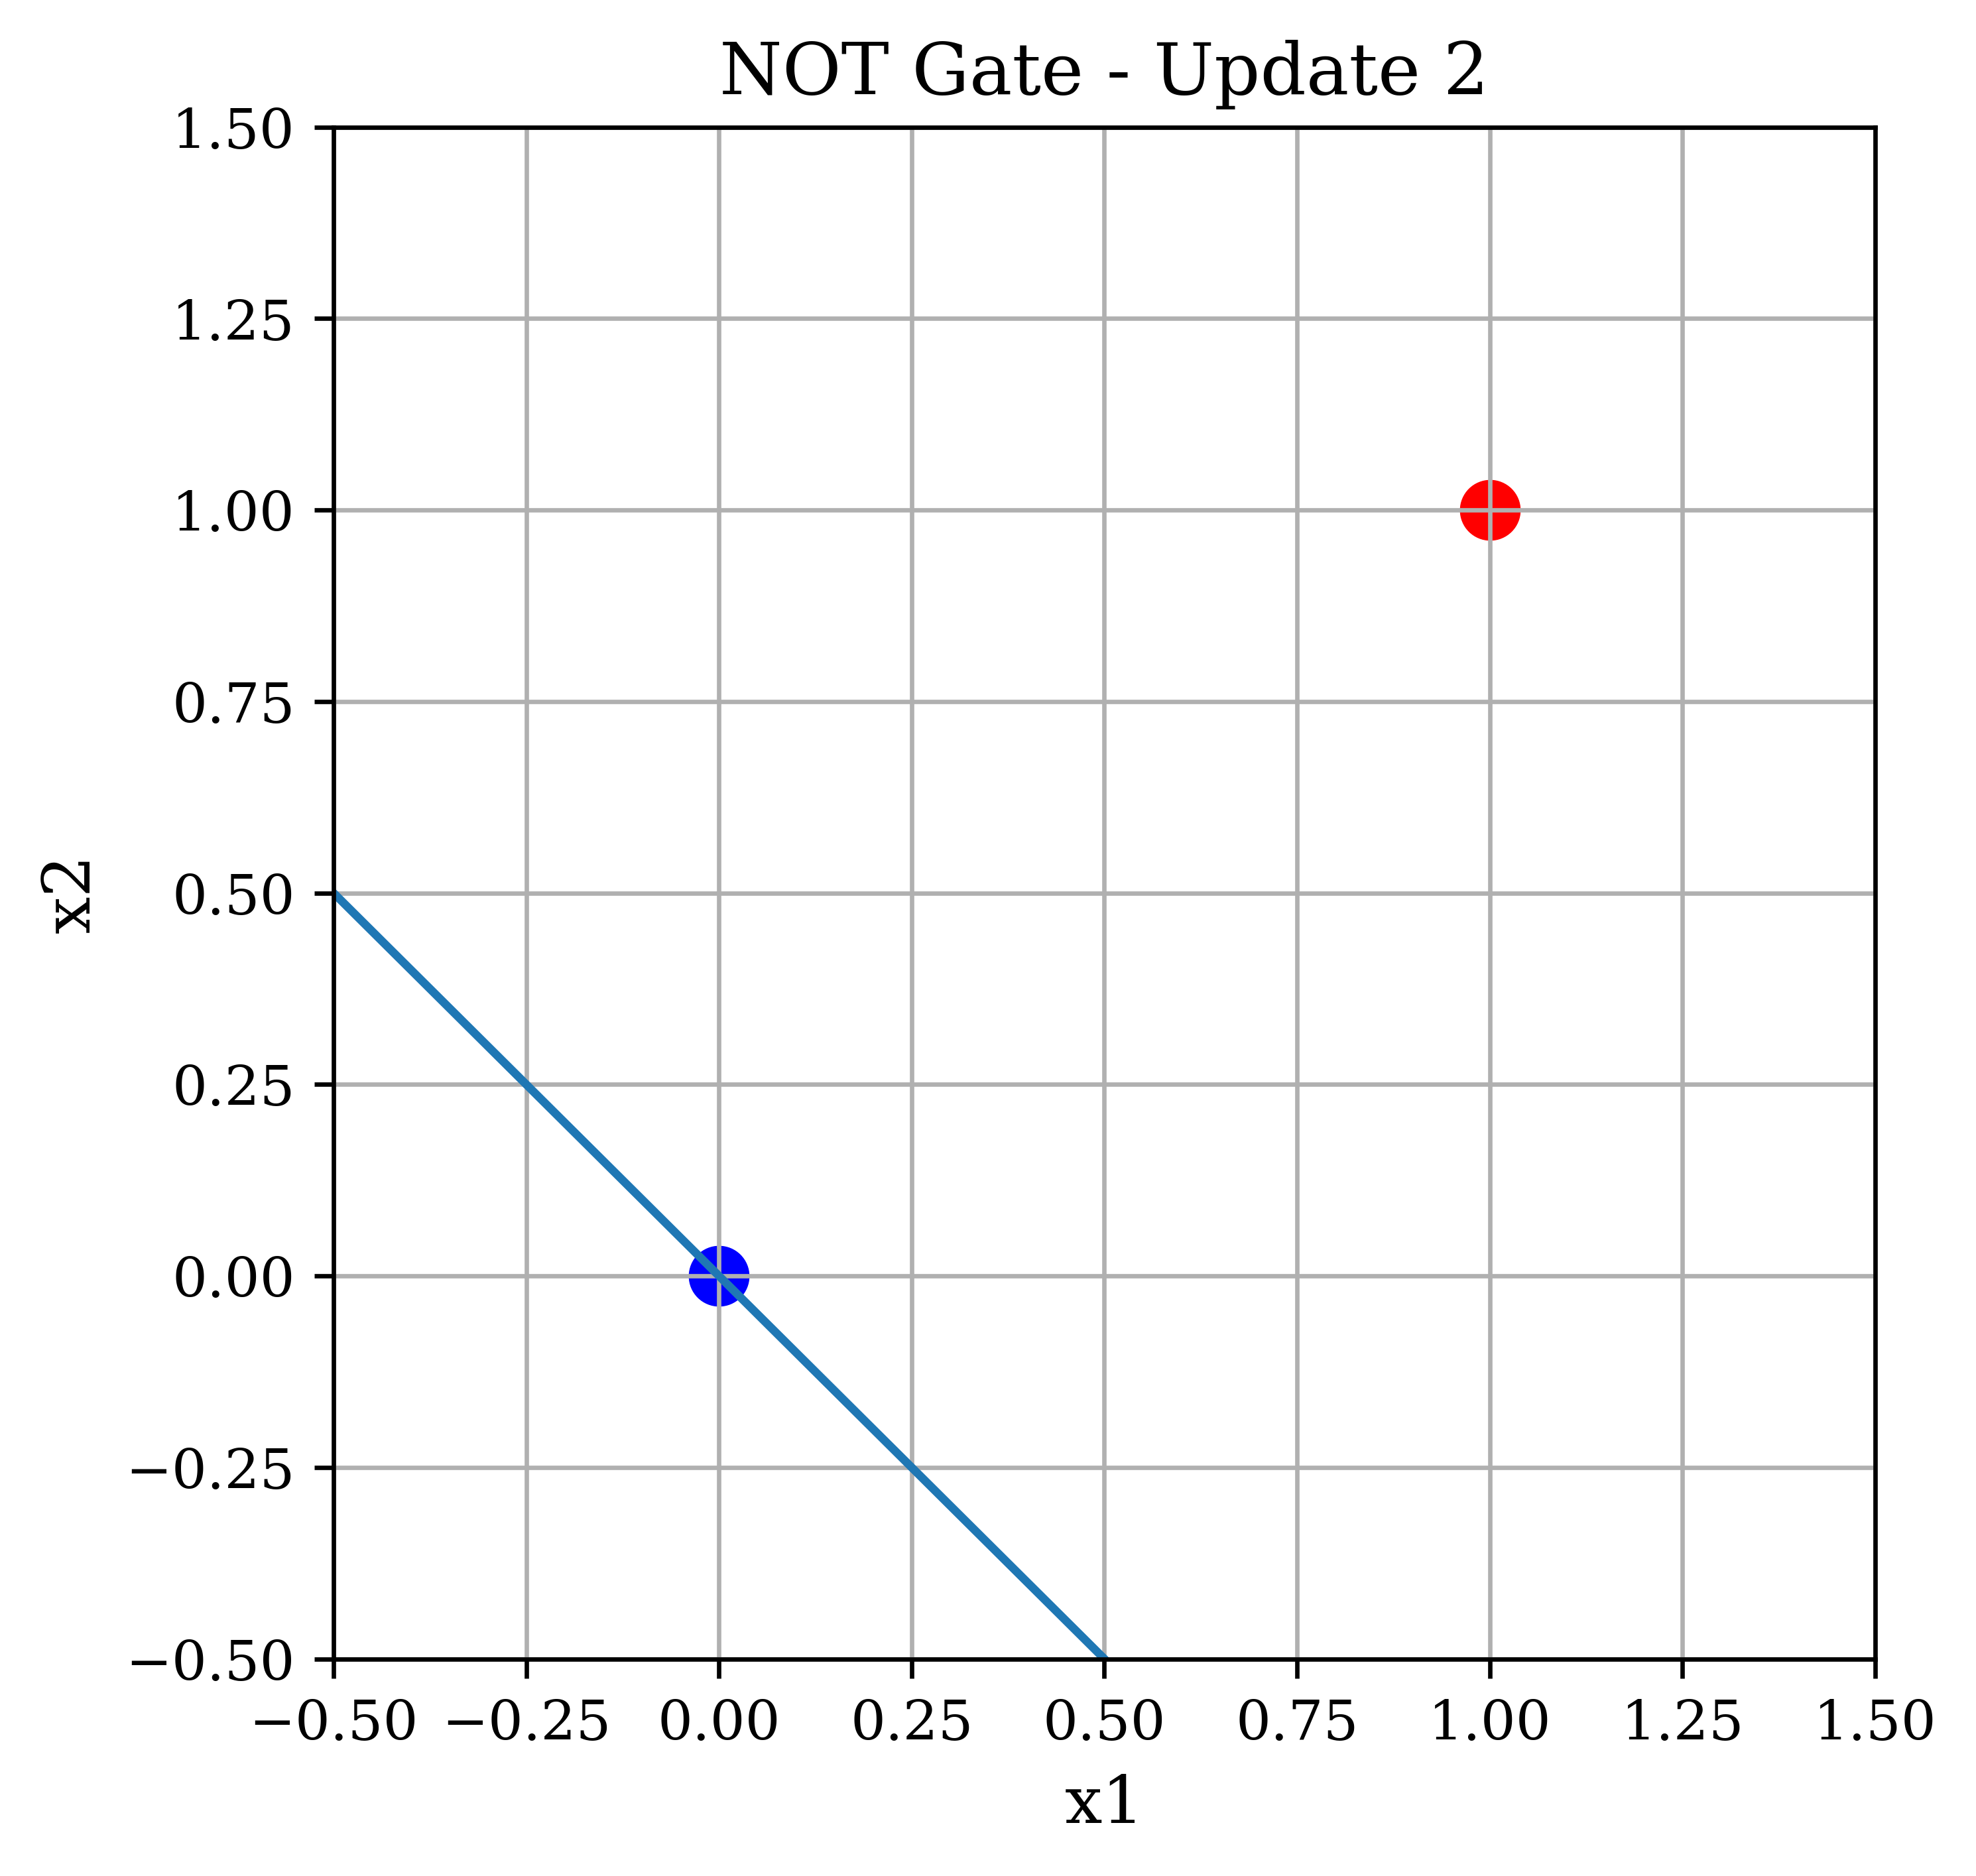

Converged after 3 epochs.

AND GATE - ALL WEIGHT UPDATES
Update 1: Weights = [-1.  0.  0.]
Update 2: Weights = [0. 1. 1.]
Update 3: Weights = [-1.  1.  1.]
Update 4: Weights = [-2.  1.  0.]
Update 5: Weights = [-1.  2.  1.]
Update 6: Weights = [-2.  2.  0.]
Update 7: Weights = [-3.  1.  0.]
Update 8: Weights = [-2.  2.  1.]
Update 9: Weights = [-3.  1.  1.]
Update 10: Weights = [-2.  2.  2.]
Update 11: Weights = [-3.  2.  1.]

Final Weights: [-3.  2.  1.]

OR GATE - ALL WEIGHT UPDATES
Update 1: Weights = [-1.  0.  0.]
Update 2: Weights = [0. 0. 1.]
Update 3: Weights = [-1.  0.  1.]
Update 4: Weights = [0. 1. 1.]
Update 5: Weights = [-1.  1.  1.]

Final Weights: [-1.  1.  1.]

NOT GATE - ALL WEIGHT UPDATES
Update 1: Weights = [-1. -1. -1.]
Update 2: Weights = [ 0. -1. -1.]

Final Weights: [ 0. -1. -1.]



In [ ]:
# ===== CELL 1: Installs =====
!apt-get -qq update > /dev/null 2>&1
!echo "ttf-mscorefonts-installer msttcorefonts/accepted-mscorefonts-eula select true" | debconf-set-selections
!apt-get -qq install -y ttf-mscorefonts-installer > /dev/null 2>&1
!fc-cache -f > /dev/null 2>&1

# Verify it actually landed on disk (this is the part that silently fails sometimes)
!fc-list | grep -i "times new roman" || echo "NOT FOUND - will need Runtime > Restart session and rerun"

!wget -q -O /content/TimesNewRoman.ttf https://github.com/justrajdeep/fonts/raw/master/Times%20New%20Roman.ttf
!wget -q -O /content/times.ttf https://github.com/FSKiller/Microsoft-Fonts/raw/main/times.ttf
!wget -q -O /content/timesbd.ttf https://github.com/FSKiller/Microsoft-Fonts/raw/main/timesbd.ttf


# ===== CELL 2: Imports, font config, plot/save configuration =====
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron as SkPerceptron
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix)

# Rebuild matplotlib's font cache so it picks up the just-installed font,
# and explicitly register the wget'd fallback fonts as a safety net in case
# the mscorefonts-installer silently failed to download the real font files
for f in os.listdir(matplotlib.get_cachedir()):
    if 'fontlist' in f:
        os.remove(os.path.join(matplotlib.get_cachedir(), f))
fm.fontManager = fm.FontManager()

for fallback_path in ["/content/TimesNewRoman.ttf", "/content/times.ttf", "/content/timesbd.ttf"]:
    if os.path.exists(fallback_path):
        fm.fontManager.addfont(fallback_path)

# Fixed list (not appended) so re-running this cell doesn't create duplicates
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['figure.dpi'] = 600
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13

PLOT_DIR = "/content/plots"
os.makedirs(PLOT_DIR, exist_ok=True)

def save_plot(fig, name):
    path = os.path.join(PLOT_DIR, f"{name}.eps")
    fig.savefig(path, format='eps', dpi=600, bbox_inches='tight')
    print(f"Saved: {path}")

print("Configured font.serif priority:", plt.rcParams['font.serif'][:3])


# ===== CELL 3: Perceptron class (AND / OR / NOT logic gates) =====
# ===== CELL 3: Perceptron class (AND / OR / NOT logic gates) =====

class Perceptron:
    def __init__(self, num_inputs, lr=1.0, epochs=10):
        self.lr = lr
        self.epochs = epochs
        self.weights = np.zeros(num_inputs + 1)   # bias + weights
        self.history = []

    def predict(self, x):
        net = self.weights[0] + np.dot(x, self.weights[1:])
        return 1 if net >= 0 else 0

    def fit(self, X, y, title):
        update_no = 1

        for epoch in range(self.epochs):
            error_count = 0

            for xi, target in zip(X, y):
                pred = self.predict(xi)
                error = target - pred

                if error != 0:
                    self.weights[1:] += self.lr * error * xi
                    self.weights[0] += self.lr * error

                    print(f"Update {update_no}")
                    print(f"Input: {xi}, Target: {target}")
                    print(f"Weights: {self.weights}\n")

                    self.history.append(self.weights.copy())
                    self.plot_boundary(X, y, title, update_no)

                    update_no += 1
                    error_count += 1

            if error_count == 0:
                print(f"Converged after {epoch+1} epochs.\n")
                break

    def plot_boundary(self, X, y, title, update_no):
        fig = plt.figure(figsize=(5, 5))

        for point, label in zip(X, y):
            if label == 1:
                plt.scatter(point[0], point[1], color='blue', s=100)
            else:
                plt.scatter(point[0], point[1], color='red', s=100)

        w0 = self.weights[0]
        w1 = self.weights[1]
        w2 = self.weights[2]

        x_vals = np.linspace(-0.5, 1.5, 100)

        if abs(w2) > 1e-6:
            y_vals = -(w0 + w1 * x_vals) / w2
            plt.plot(x_vals, y_vals)

        elif abs(w1) > 1e-6:
            plt.axvline(-w0 / w1)

        plt.xlim(-0.5, 1.5)
        plt.ylim(-0.5, 1.5)
        plt.grid(True)

        plt.title(f"{title} - Update {update_no}")
        plt.xlabel("x1")
        plt.ylabel("x2")

        safe_title = title.replace(" ", "_").lower()
        save_plot(fig, f"{safe_title}_update_{update_no}")

        plt.show()
        plt.close(fig)



###############################################
# AND Gate
###############################################

print("=" * 60)
print("AND GATE")
print("=" * 60)

X_and = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_and = np.array([0, 0, 0, 1])

p_and = Perceptron(num_inputs=2, lr=1, epochs=10)
p_and.fit(X_and, y_and, "AND Gate")



###############################################
# OR Gate
###############################################

print("=" * 60)
print("OR GATE")
print("=" * 60)

X_or = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_or = np.array([0, 1, 1, 1])

p_or = Perceptron(num_inputs=2, lr=1, epochs=10)
p_or.fit(X_or, y_or, "OR Gate")



###############################################
# NOT Gate
###############################################

print("=" * 60)
print("NOT GATE")
print("=" * 60)

# Duplicate input for plotting compatibility

X_not = np.array([
    [0, 0],
    [1, 1]
])

y_not = np.array([1, 0])

p_not = Perceptron(num_inputs=2, lr=1, epochs=10)
p_not.fit(X_not, y_not, "NOT Gate")



###############################################
# Print all weight updates together
###############################################

def print_all_updates(perceptron, gate_name):

    print("=" * 60)
    print(f"{gate_name} GATE - ALL WEIGHT UPDATES")
    print("=" * 60)

    for i, weights in enumerate(perceptron.history, start=1):
        print(f"Update {i}: Weights = {weights}")

    print(f"\nFinal Weights: {perceptron.weights}")
    print()



print_all_updates(p_and, "AND")
print_all_updates(p_or, "OR")
print_all_updates(p_not, "NOT")

In [ ]:
# ===== CELL 15: Zip and download all plots =====
import shutil
from google.colab import files

zip_path = "/content/plots"
shutil.make_archive(zip_path, 'zip', PLOT_DIR)

print("Files in archive:")
for f in os.listdir(PLOT_DIR):
    print(" -", f)

files.download(zip_path + ".zip")

Files in archive:
 - or_gate_update_1.eps
 - or_gate_update_3.eps
 - not_gate_update_2.eps
 - and_gate_update_3.eps
 - and_gate_update_1.eps
 - and_gate_update_2.eps
 - and_gate_update_8.eps
 - and_gate_update_11.eps
 - not_gate_update_1.eps
 - or_gate_update_4.eps
 - or_gate_update_2.eps
 - and_gate_update_5.eps
 - and_gate_update_6.eps
 - or_gate_update_5.eps
 - and_gate_update_7.eps
 - and_gate_update_10.eps
 - and_gate_update_9.eps
 - and_gate_update_4.eps


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>